(mmm_yoy_target_transform)=
# Year-over-Year Target Transform: a Custom MMM for Highly Seasonal KPIs

For KPIs whose variance is dominated by an annual cycle, a useful reparameterisation is to stop
modelling the level and model the **year-over-year ratio** instead. The prior cycle's observed
level becomes the seasonal baseline, so seasonality enters multiplicatively and for free: no
Fourier basis, no trend component, no per-unit seasonal profile to estimate.

This notebook builds that model from scratch with plain PyMC plus PyMC-Marketing components,
following the strategy of {ref}`mmm_components` and {ref}`mmm_custom_splines`. We generate the
data from a generative PyMC model in the style of {ref}`mmm_data_generator`, fit the
year-over-year model, fit a vanilla additive {class}`~pymc_marketing.mmm.mmm.MMM` with Fourier
seasonality on the same panel, and compare them out of sample.

The transform is cheap to implement, but it is not just a preprocessing step: it changes what the
likelihood can identify, and therefore what a "channel contribution" number means. A large part
of this notebook is about that.

**Roadmap**

1. The transform, and the **reference map** $r(t)$ that makes it work with moving holidays.
2. A generative PyMC model for a highly seasonal, multi-unit panel.
3. The custom year-over-year model, built from `GeometricAdstock` and `LogisticSaturation`.
4. A vanilla additive MMM with Fourier seasonality on the same data.
5. Holdout comparison, parameter recovery, and the two contribution bases.

```{tip}
*Why a custom model?*
The {class}`~pymc_marketing.mmm.mmm.MMM` class covers a lot of ground, but the year-over-year
transform touches `build_model`, not just preprocessing: every driver has to enter as a
**within-pair contrast**, and that differencing happens *after* adstock and saturation. Writing
it as a PyMC model keeps the structure visible. The PyMC-Marketing components still do the heavy
lifting, so there is no need to reimplement adstock or saturation.
```

## Prepare Notebook

In [1]:
from collections import Counter

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import pytensor.tensor as pt
import pytensor.xtensor as ptx
import xarray as xr
from pymc import do
from pymc_extras.prior import Prior

from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

seed: int = sum(map(ord, "mmm_yoy_target_transform"))
rng: np.random.Generator = np.random.default_rng(seed=seed)

## The transform

Let $y_{u,t}$ be the KPI for unit $u$ (store, region, product) at period $t$, and let $r(t)$ be a
**reference map** sending each period to its counterpart one cycle earlier. We model the ratio

$$
z_{u,t} \;=\; \frac{y_{u,t}}{y_{u,\,r(t)}}
$$

with an additive linear predictor in which every driver enters as a within-pair contrast

$$
z_{u,t} \;=\; \alpha_u
\;+\; \sum_c \bigl[f_c(a_{c,u,t}) - f_c(a_{c,u,\,r(t)})\bigr]
\;+\; \sum_k \gamma_k \bigl[x_{k,u,t} - x_{k,u,\,r(t)}\bigr]
\;+\; \varepsilon_{u,t},
$$

where $f_c$ is the usual adstock-then-saturation composition (in PyMC-Marketing the channel
coefficient lives inside $f_c$) and $x_k$ are controls in raw driver units. Levels are recovered
exactly by $y_{u,t} = y_{u,r(t)} \cdot z_{u,t}$.

Three things fall out immediately.

- **Seasonality is absorbed multiplicatively.** Any part of the seasonal shape that repeats cycle
  over cycle is already in $y_{u,r(t)}$. The model only has to explain departures from last cycle.
- **The per-unit baseline collapses to a scalar.** $\alpha_u$ is that unit's typical growth rate.
  There is no per-unit seasonal curve, which is where most of the parameters in a level-space
  panel MMM go.
- **Heteroscedasticity is largely handled.** Additive noise in ratio space is proportional noise
  in level space, which is usually closer to the truth for sales-like KPIs.

### The reference map is the interesting part

$r(t) = t - 52$ works only if the calendar repeats exactly. It does not. Moving holidays (Easter,
Ramadan, Chinese New Year, Thanksgiving-relative weeks) shift by a variable number of weeks, and
a blind 52-week lag pairs a holiday week against a non-holiday week, injecting a spurious spike
into $z$ precisely where the KPI is largest. So $r$ has to be **event-anchored**, with a shoulder
window around each moving anchor.

Realigning a window by $k$ periods against an unshifted base mapping necessarily produces $k$
**duplicated** and $k$ **orphaned** reference periods, capped by the window width. Only $k = 0$ is
clean. That is a structural property rather than an implementation bug, so the builder reports it.

In [2]:
def build_reference_map(
    n_periods: int,
    period: int,
    anchors: tuple[tuple[int, int], ...] = (),
    pad: int = 0,
) -> tuple[np.ndarray, list[int], list[int]]:
    """Map each period to its counterpart one cycle earlier.

    Parameters
    ----------
    n_periods : int
        Length of the full series.
    period : int
        Base cycle length, e.g. 52 for weekly data.
    anchors : tuple of (current, prior) index pairs
        Moving-event pairs. ``current`` is the index of the event in the current cycle and
        ``prior`` the index of the same event one cycle earlier.
    pad : int
        Number of shoulder periods on each side of an anchor that get dragged with it.

    Returns
    -------
    reference : np.ndarray
        ``reference[t]`` is the index of the reference period for ``t``, negative where no
        reference exists (the first cycle).
    duplicated : list of int
        Prior-cycle periods used as the reference for more than one current period.
    orphaned : list of int
        Prior-cycle periods that are the reference for nothing.
    """
    reference = np.arange(n_periods) - period

    for current, prior in anchors:
        for offset in range(-pad, pad + 1):
            t = current + offset
            if 0 <= t < n_periods:
                reference[t] = prior + offset

    used = reference[reference >= 0]
    counts = Counter(used.tolist())
    duplicated = sorted(p for p, n in counts.items() if n > 1)
    orphaned = sorted(set(range(n_periods - period)) - set(used.tolist()))
    return reference, duplicated, orphaned

## Synthetic data

We build a weekly panel of four stores over six years. The design is deliberately friendly to the
ratio model and hostile to a level-space one, so that the comparison isolates the mechanism rather
than the tuning:

- a strong annual seasonal shape that is **inherited** cycle over cycle rather than re-drawn,
- a **moving holiday** whose week-of-year drifts by up to three weeks,
- three media channels, one of which is held at a **flat always-on plan** (constant spend, so its
  year-over-year contrast is exactly zero), and
- **proportional** observation noise.

We come back to the fairness of that choice in the conclusions.

In [3]:
n_years = 6
period = 52
n_dates = n_years * period

date_index = pd.date_range(start="2019-01-07", freq="W-MON", periods=n_dates)

unit_names = ["north", "south", "east", "west"]
channel_columns = ["tv", "search", "sponsorship"]
control_columns = ["discount"]

l_max = 8

coords_data = {
    "date": date_index,
    "unit": unit_names,
    "channel": channel_columns,
    "control": control_columns,
}

n_units = len(unit_names)
n_channels = len(channel_columns)

# The moving holiday: week-of-year of the event in each of the six cycles.
holiday_week_of_year = [12, 13, 15, 14, 12, 13]
holiday_index = [period * y + w for y, w in enumerate(holiday_week_of_year)]

print(f"holiday period index per cycle: {holiday_index}")

holiday period index per cycle: [12, 65, 119, 170, 220, 273]


### Reference map for this calendar

Each cycle's holiday is anchored to the previous cycle's holiday, with a one-week shoulder on each
side.

In [4]:
anchors = tuple(zip(holiday_index[1:], holiday_index[:-1], strict=True))

reference_map, duplicated, orphaned = build_reference_map(
    n_periods=n_dates, period=period, anchors=anchors, pad=1
)
naive_reference_map, _, _ = build_reference_map(n_periods=n_dates, period=period)

print(f"anchors (current <- prior): {anchors}")
print(f"duplicated reference periods: {duplicated}")
print(f"orphaned reference periods:   {orphaned}")

anchors (current <- prior): ((65, 12), (119, 65), (170, 119), (220, 170), (273, 220))
duplicated reference periods: [11, 64, 65, 120, 170, 171, 219]
orphaned reference periods:   [14, 67, 68, 117, 167, 168, 222]


```{warning}
Because $r$ is not injective on prior-cycle periods, $\sum_t y_{u,r(t)} \neq$ prior-cycle total.
Period-level reads are unaffected. Cycle-level roll-ups are not: they double-count one period's
level and drop another's, and around a moving holiday those are exactly the two periods whose
levels differ most. Any aggregation utility built on this transform has to either surface the
defect or define an explicit convention for it.
```

Let us look at the seam directly, around the third cycle's holiday.

In [5]:
window = np.arange(holiday_index[2] - 4, holiday_index[2] + 5)

seam_df = pd.DataFrame(
    {
        "period t": window,
        "base r(t) = t - 52": naive_reference_map[window],
        "anchored r(t)": reference_map[window],
        "shift": reference_map[window] - naive_reference_map[window],
        "t is holiday": [t in holiday_index for t in window],
        "r(t) is holiday": [r in holiday_index for r in reference_map[window]],
    }
).set_index("period t")

seam_df

,base r(t) = t - 52,anchored r(t),shift,t is holiday,r(t) is holiday
period t,,,,,
115,63,63,0,False,False
116,64,64,0,False,False
117,65,65,0,False,True
118,66,64,-2,False,False
119,67,65,-2,True,True
120,68,66,-2,False,False
121,69,69,0,False,False
122,70,70,0,False,False
123,71,71,0,False,False


The base map sends the holiday week 119 to the non-holiday week 67. The anchored map sends it to
week 65, which is the holiday in the previous cycle. That is the whole point of anchoring, and the
price is the duplicate/orphan pair visible at the window edge.

### Generating correlated channel spend

Media spend comes from a small PyMC model: a multivariate normal over channels with an LKJ prior
on the correlation structure (brands rarely move one channel at a time), per unit-channel
intercepts and trends, and a softplus to keep spend non-negative. The discount control is drawn
from a Beta.

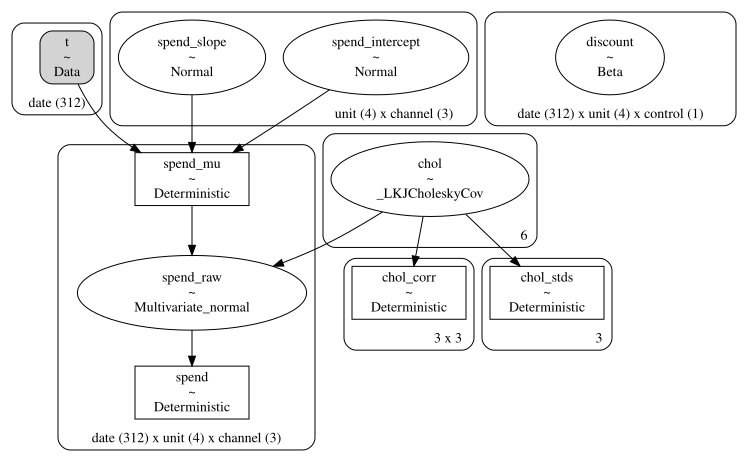

In [6]:
t_scaled = np.arange(n_dates) / n_dates

with pm.Model(coords=coords_data) as covariates_model:
    t_data = pm.Data("t", t_scaled, dims="date")

    chol, _, _ = pm.LKJCholeskyCov(
        "chol",
        n=n_channels,
        eta=3,
        sd_dist=pm.Exponential.dist(lam=1 / 1.5),
    )

    spend_intercept = pm.Normal(
        "spend_intercept", mu=0.0, sigma=0.7, dims=("unit", "channel")
    )
    spend_slope = pm.Normal("spend_slope", mu=0.0, sigma=0.7, dims=("unit", "channel"))

    spend_mu = pm.Deterministic(
        "spend_mu",
        spend_intercept + spend_slope * t_data[:, None, None],
        dims=("date", "unit", "channel"),
    )

    spend_raw = pm.MvNormal(
        "spend_raw", mu=spend_mu, chol=chol, dims=("date", "unit", "channel")
    )
    spend = pm.Deterministic(
        "spend", pt.softplus(spend_raw), dims=("date", "unit", "channel")
    )

    discount = pm.Beta(
        "discount", alpha=1.2, beta=6.0, dims=("date", "unit", "control")
    )

pm.model_to_graphviz(covariates_model)

In [7]:
spend_draw, discount_draw = pm.draw(
    [covariates_model["spend"], covariates_model["discount"]], draws=1, random_seed=rng
)

# The sponsorship channel is always-on at a flat plan: constant over time, hence identical
# cycle over cycle by construction.
sponsorship = channel_columns.index("sponsorship")
spend_draw[:, :, sponsorship] = spend_draw[:, :, sponsorship].mean(
    axis=0, keepdims=True
)

channel_data = xr.DataArray(
    spend_draw,
    dims=("date", "unit", "channel"),
    coords={"date": date_index, "unit": unit_names, "channel": channel_columns},
)
control_data = xr.DataArray(
    discount_draw,
    dims=("date", "unit", "control"),
    coords={"date": date_index, "unit": unit_names, "control": control_columns},
)

# Scale media to roughly [0, 1] once, up front, so that the ground-truth saturation parameters and
# both fitted models all live on the same input scale.
channel_scale = channel_data.max(("date", "unit"))
channel_scaled = channel_data / channel_scale

channel_scaled.isel(date=slice(0, 3)).to_dataframe(name="scaled_spend").head()

scaled_spend
date       unit  channel                  
2019-01-07 north tv               0.697533
                 search           0.000024
                 sponsorship      1.000000
           south tv               0.241058
                 search           0.000126

Check the design. The sponsorship channel varies across units but not across time, so its
year-over-year contrast is exactly zero, while `tv` and `search` move.

In [8]:
spend_values = channel_scaled.transpose("date", "unit", "channel").to_numpy()

# Every period after the first cycle has a reference. The first ``l_max`` of those are dropped
# from the modelled window so that adstock has warmed up on both sides of every pair; they are
# still generated, because the level recursion needs them.
obs_idx_all = np.arange(period, n_dates)
obs_idx_model = np.arange(period + l_max, n_dates)

contrast_summary = pd.DataFrame(
    {
        "std of spend level": spend_values.std(axis=(0, 1)),
        "std of year-over-year spend contrast": (
            spend_values[obs_idx_model] - spend_values[reference_map[obs_idx_model]]
        ).std(axis=(0, 1)),
    },
    index=pd.Index(channel_columns, name="channel"),
)

contrast_summary

,std of spend level,std of year-over-year spend contrast
channel,,
tv,0.208739,0.255946
search,0.221408,0.318187
sponsorship,0.268643,0.000000


Text(0.5, 0.98, 'Media Spend by Channel and Unit')

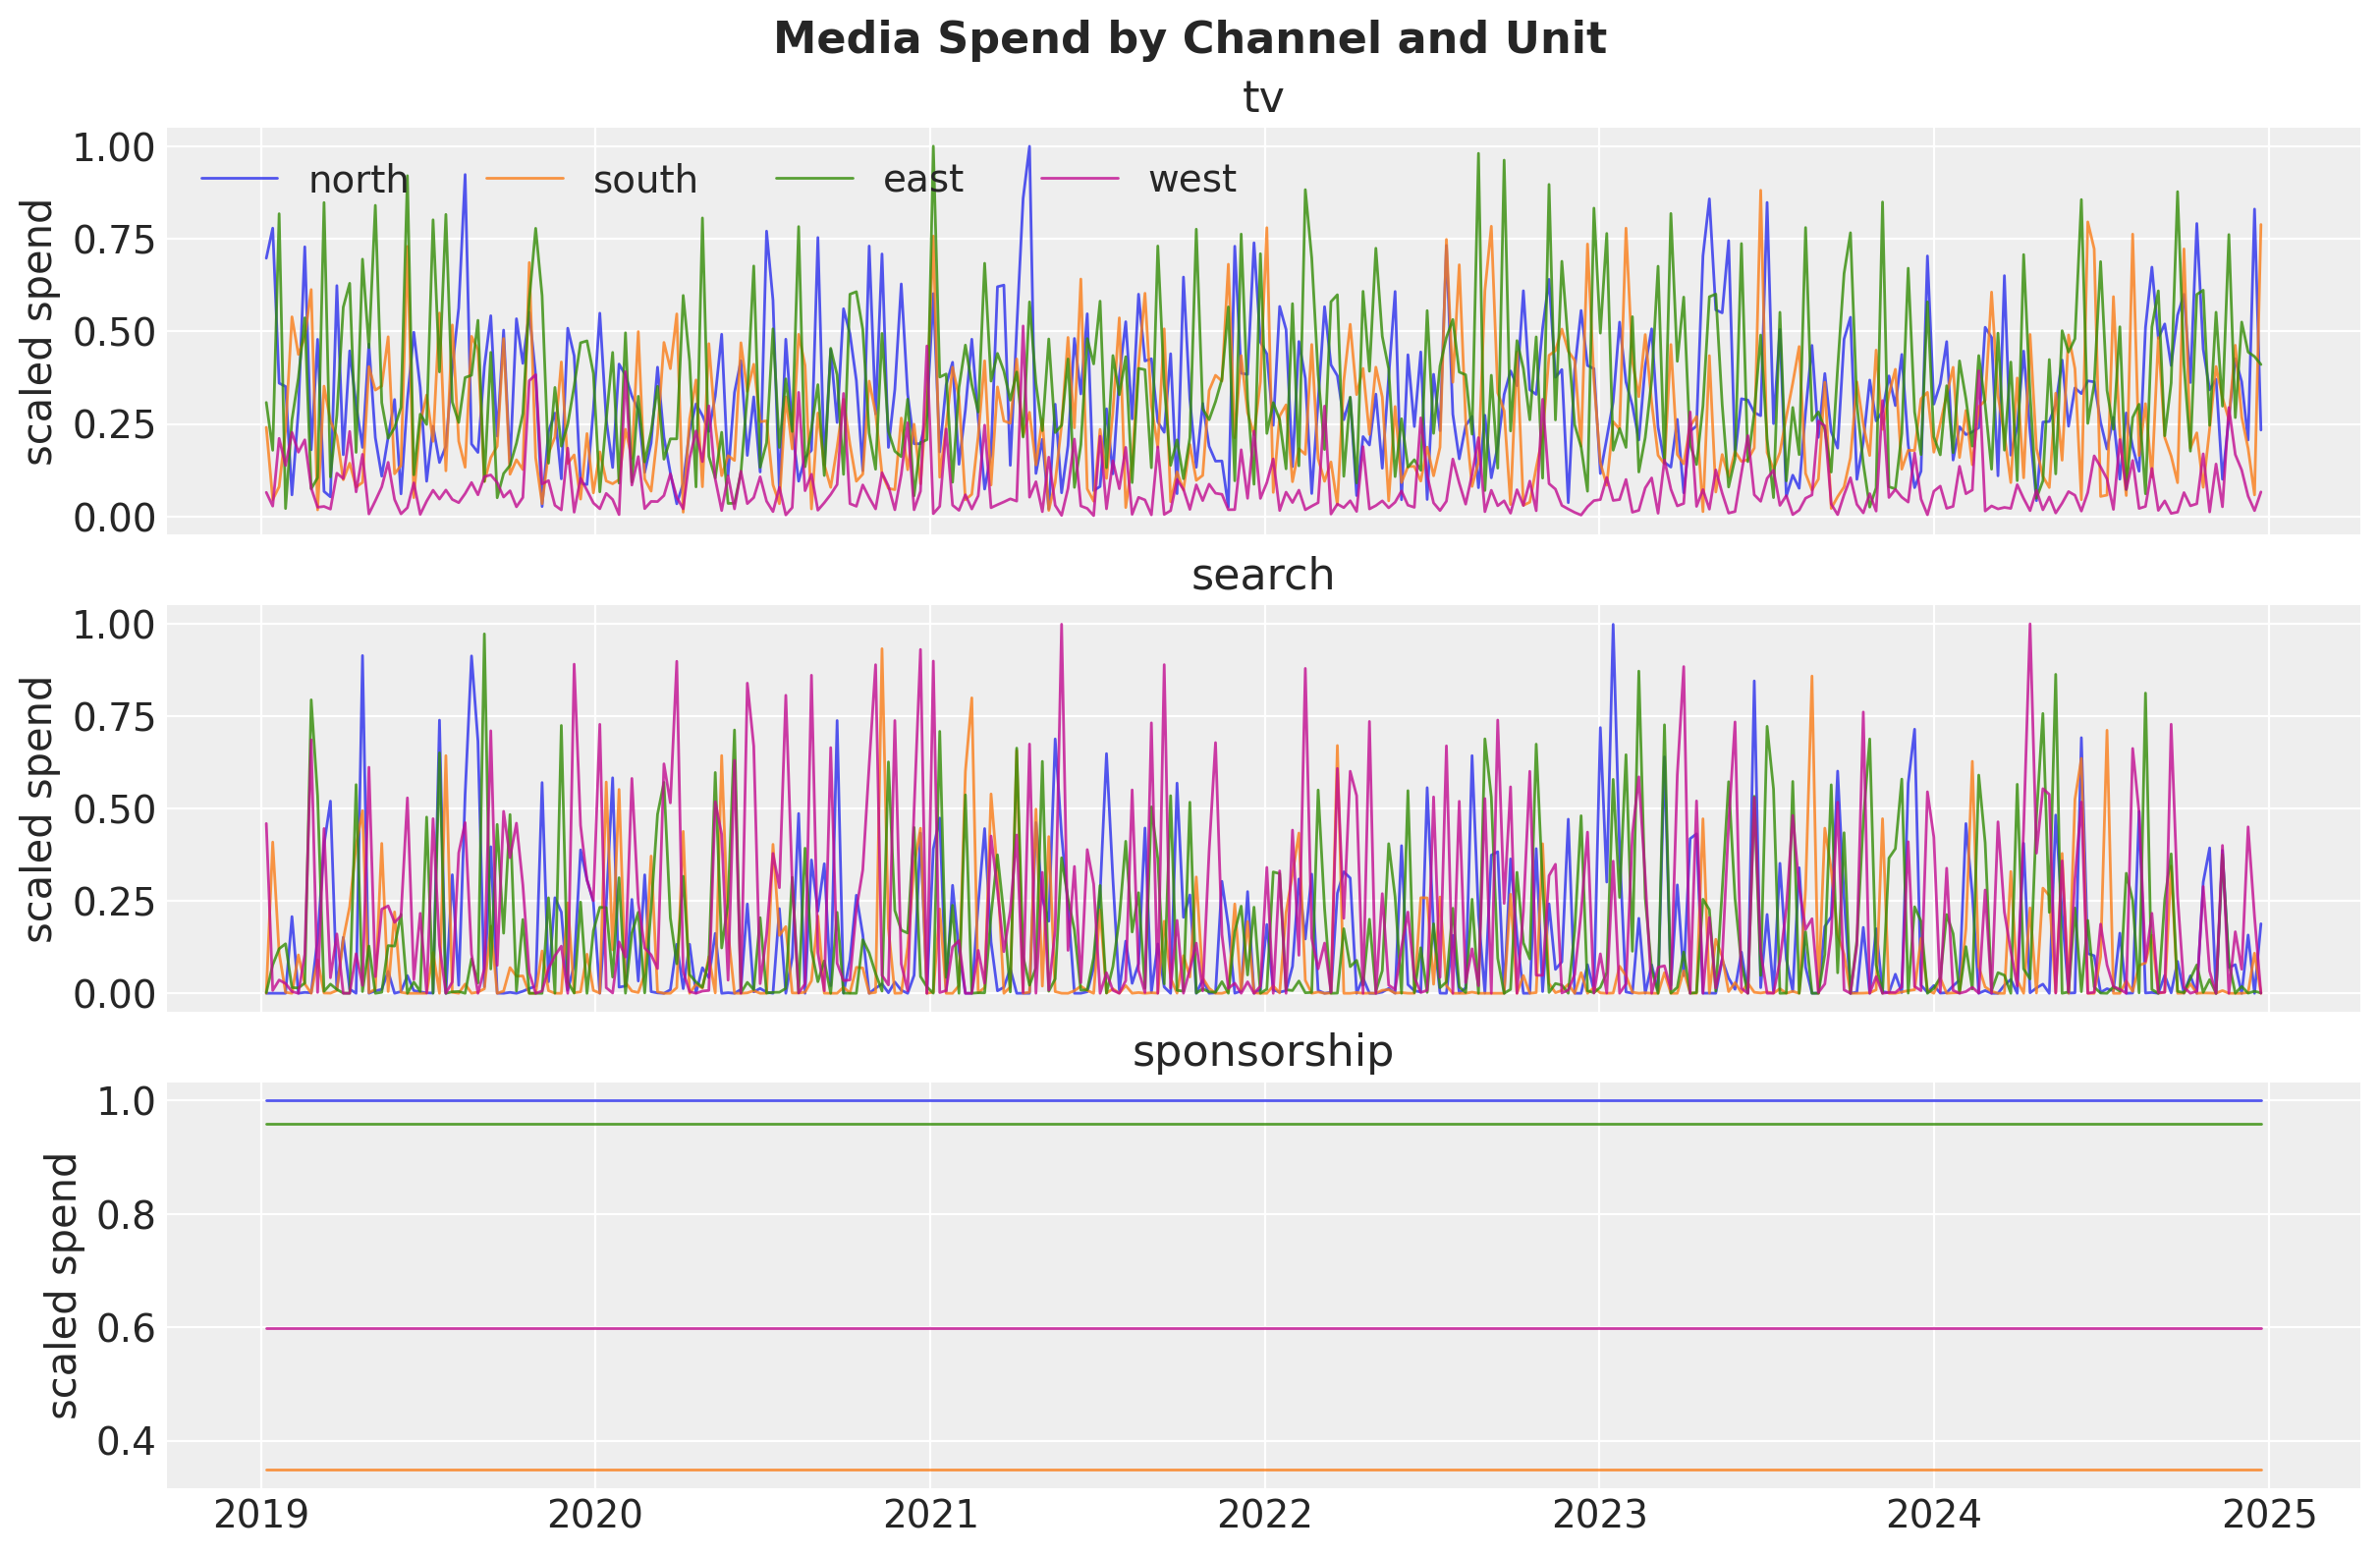

In [9]:
fig, axes = plt.subplots(
    nrows=n_channels, figsize=(12, 2.6 * n_channels), sharex=True, layout="constrained"
)

for ax, channel in zip(axes, channel_columns, strict=True):
    for unit in unit_names:
        ax.plot(
            date_index,
            channel_scaled.sel(channel=channel, unit=unit),
            alpha=0.8,
            linewidth=1,
            label=unit,
        )
    ax.set_title(channel)
    ax.set_ylabel("scaled spend")

axes[0].legend(loc="upper left", ncol=n_units)
fig.suptitle("Media Spend by Channel and Unit", fontsize=16, fontweight="bold")

### Ground-truth parameters

The saturation `beta` values are in **ratio points**: a full swing of `tv` moves the year-over-year
ratio by up to 0.13, that is 13 percent of the reference level.

In [10]:
adstock_alpha_true = np.array([0.55, 0.25, 0.40])
saturation_lam_true = np.array([2.5, 4.0, 3.0])
saturation_beta_true = np.array([0.13, 0.08, 0.06])
gamma_control_true = np.array([0.18])
intercept_true = np.array([1.03, 1.00, 0.98, 1.05])
z_sigma_true = np.array([0.030, 0.035, 0.028, 0.032])

ground_truth = pd.DataFrame(
    {
        "adstock_alpha": adstock_alpha_true,
        "saturation_lam": saturation_lam_true,
        "saturation_beta": saturation_beta_true,
    },
    index=pd.Index(channel_columns, name="channel"),
)

ground_truth

,adstock_alpha,saturation_lam,saturation_beta
channel,,,
tv,0.55,2.5,0.13
search,0.25,4.0,0.08
sponsorship,0.40,3.0,0.06


## The year-over-year model

The model is wrapped in a function so that the *same* graph serves three purposes: data generation
(with the parameters clamped by {func}`pymc.do`), inference on the training window, and
out-of-sample prediction on a different observation window.

The one structural subtlety: $f_c$ is evaluated on the **full contiguous series** and only then
gathered at $t$ and $r(t)$. Gathering first and adstocking afterwards would build the reference
period's carryover out of the current period's history, which is wrong.

In [11]:
adstock = GeometricAdstock(
    l_max=l_max,
    priors={"alpha": Prior("Beta", alpha=1, beta=3, dims="channel")},
)

saturation = LogisticSaturation(
    priors={
        "lam": Prior("Gamma", alpha=3, beta=1, dims="channel"),
        "beta": Prior("HalfNormal", sigma=0.2, dims="channel"),
    }
)

In [12]:
def build_yoy_model(
    obs_idx: np.ndarray,
    z_observed: xr.DataArray | None = None,
) -> pm.Model:
    """Build the year-over-year ratio model on a given observation window."""
    ref_idx = reference_map[obs_idx]
    if np.any(ref_idx < 0):
        raise ValueError("every modelled period needs a reference period")

    coords = {
        "date": date_index,
        "obs_date": date_index[obs_idx],
        "unit": unit_names,
        "channel": channel_columns,
        "control": control_columns,
    }

    if z_observed is None:
        z_observed = xr.DataArray(
            np.ones((len(obs_idx), n_units)),
            dims=("obs_date", "unit"),
            coords={"obs_date": coords["obs_date"], "unit": unit_names},
        )

    with pm.Model(coords=coords) as model:
        channel_data_ = pmd.Data("channel_data", channel_scaled)
        control_data_ = pmd.Data("control_data", control_data)

        t_sel = ptx.as_xtensor(obs_idx, dims=("obs_date",))
        r_sel = ptx.as_xtensor(ref_idx, dims=("obs_date",))

        # Adstock then saturation on the whole series, shared parameters, and only then gather.
        f_full = saturation.apply(adstock.apply(channel_data_, core_dim="date"))

        f_current = pmd.Deterministic(
            "f_current",
            f_full.isel(date=t_sel),
            dims=("obs_date", "unit", "channel"),
        )
        f_reference = pmd.Deterministic(
            "f_reference",
            f_full.isel(date=r_sel),
            dims=("obs_date", "unit", "channel"),
        )
        channel_contribution = pmd.Deterministic(
            "channel_contribution",
            f_current - f_reference,
            dims=("obs_date", "unit", "channel"),
        )

        # Controls enter as raw driver differences through a linear coefficient.
        gamma_control = pmd.Normal("gamma_control", mu=0.0, sigma=0.5, dims="control")
        control_contribution = pmd.Deterministic(
            "control_contribution",
            gamma_control
            * (control_data_.isel(date=t_sel) - control_data_.isel(date=r_sel)),
            dims=("obs_date", "unit", "control"),
        )

        # The per-unit baseline is a scalar: that unit's typical growth rate.
        intercept = pmd.Normal("intercept", mu=1.0, sigma=0.15, dims="unit")

        mu = pmd.Deterministic(
            "mu",
            intercept
            + channel_contribution.sum("channel")
            + control_contribution.sum("control"),
            dims=("obs_date", "unit"),
        )

        z_sigma = pmd.HalfNormal("z_sigma", sigma=0.1, dims="unit")

        pmd.Normal(
            "z", mu=mu, sigma=z_sigma, observed=z_observed, dims=("obs_date", "unit")
        )

    return model

### Forward-simulating the ratio

We clamp every stochastic node to its ground-truth value with `do`, then draw one realisation of
$z$. This is the strategy of {ref}`mmm_data_generator`: the probabilistic model becomes a
deterministic forward simulator, aside from the observation noise.

In [13]:
generator_model = build_yoy_model(obs_idx_all)

generator_model = do(
    generator_model,
    {
        "adstock_alpha": adstock_alpha_true,
        "saturation_lam": saturation_lam_true,
        "saturation_beta": saturation_beta_true,
        "gamma_control": gamma_control_true,
        "intercept": intercept_true,
        "z_sigma": z_sigma_true,
    },
)

with generator_model:
    idata_generated = pm.sample_prior_predictive(
        draws=1,
        var_names=["z", "channel_contribution", "control_contribution", "mu"],
        random_seed=rng,
    )

z_true = (
    idata_generated.prior_predictive["z"]
    .sel(chain=0, draw=0)
    .transpose("obs_date", "unit")
)
z_true

Sampling: [z]


<xarray.DataArray 'z' (obs_date: 260, unit: 4)> Size: 8kB
array([[1.09500089, 1.0117295 , 1.1086697 , 1.07228556],
       [1.0344127 , 0.93550999, 0.9572813 , 1.15332259],
       [1.12550883, 0.97297139, 0.9531568 , 1.02388082],
       ...,
       [1.03973814, 0.99263828, 1.01609629, 1.0458967 ],
       [1.05694074, 1.03898896, 1.00008776, 1.09483559],
       [1.08126822, 0.94612355, 1.01016987, 1.0598834 ]], shape=(260, 4))
Coordinates:
  * obs_date  (obs_date) datetime64[ns] 2kB 2020-01-06 2020-01-13 ... 2024-12-23
  * unit      (unit) <U5 80B 'north' 'south' 'east' 'west'
    chain     int64 8B 0
    draw      int64 8B 0

### From ratios to levels

The first cycle is the seed: a smooth annual shape scaled by each unit's size, with the holiday
bump at its year-zero position. Everything after that comes from the recursion
$y_{u,t} = y_{u,r(t)} \cdot z_{u,t}$, so the seasonal shape, the trend and the holiday all
propagate through the reference map. The moving holiday needs no separate term: the anchored
reference map moves it.

In [14]:
week_of_year = np.arange(period)
seasonal_shape = (
    1.0
    + 0.45 * np.sin(2 * np.pi * (week_of_year - 8) / period)
    + 0.18 * np.cos(4 * np.pi * week_of_year / period)
)
seasonal_shape[holiday_week_of_year[0]] *= 1.55

unit_size = np.array([1000.0, 700.0, 1350.0, 900.0])

y = np.zeros((n_dates, n_units))
y[:period] = seasonal_shape[:, None] * unit_size[None, :]

z_values = z_true.to_numpy()
for position, t in enumerate(obs_idx_all):
    y[t] = y[reference_map[t]] * z_values[position]

target_data = xr.DataArray(
    y, dims=("date", "unit"), coords={"date": date_index, "unit": unit_names}
)

Text(0.5, 0.98, 'Synthetic Panel: a Highly Seasonal KPI')

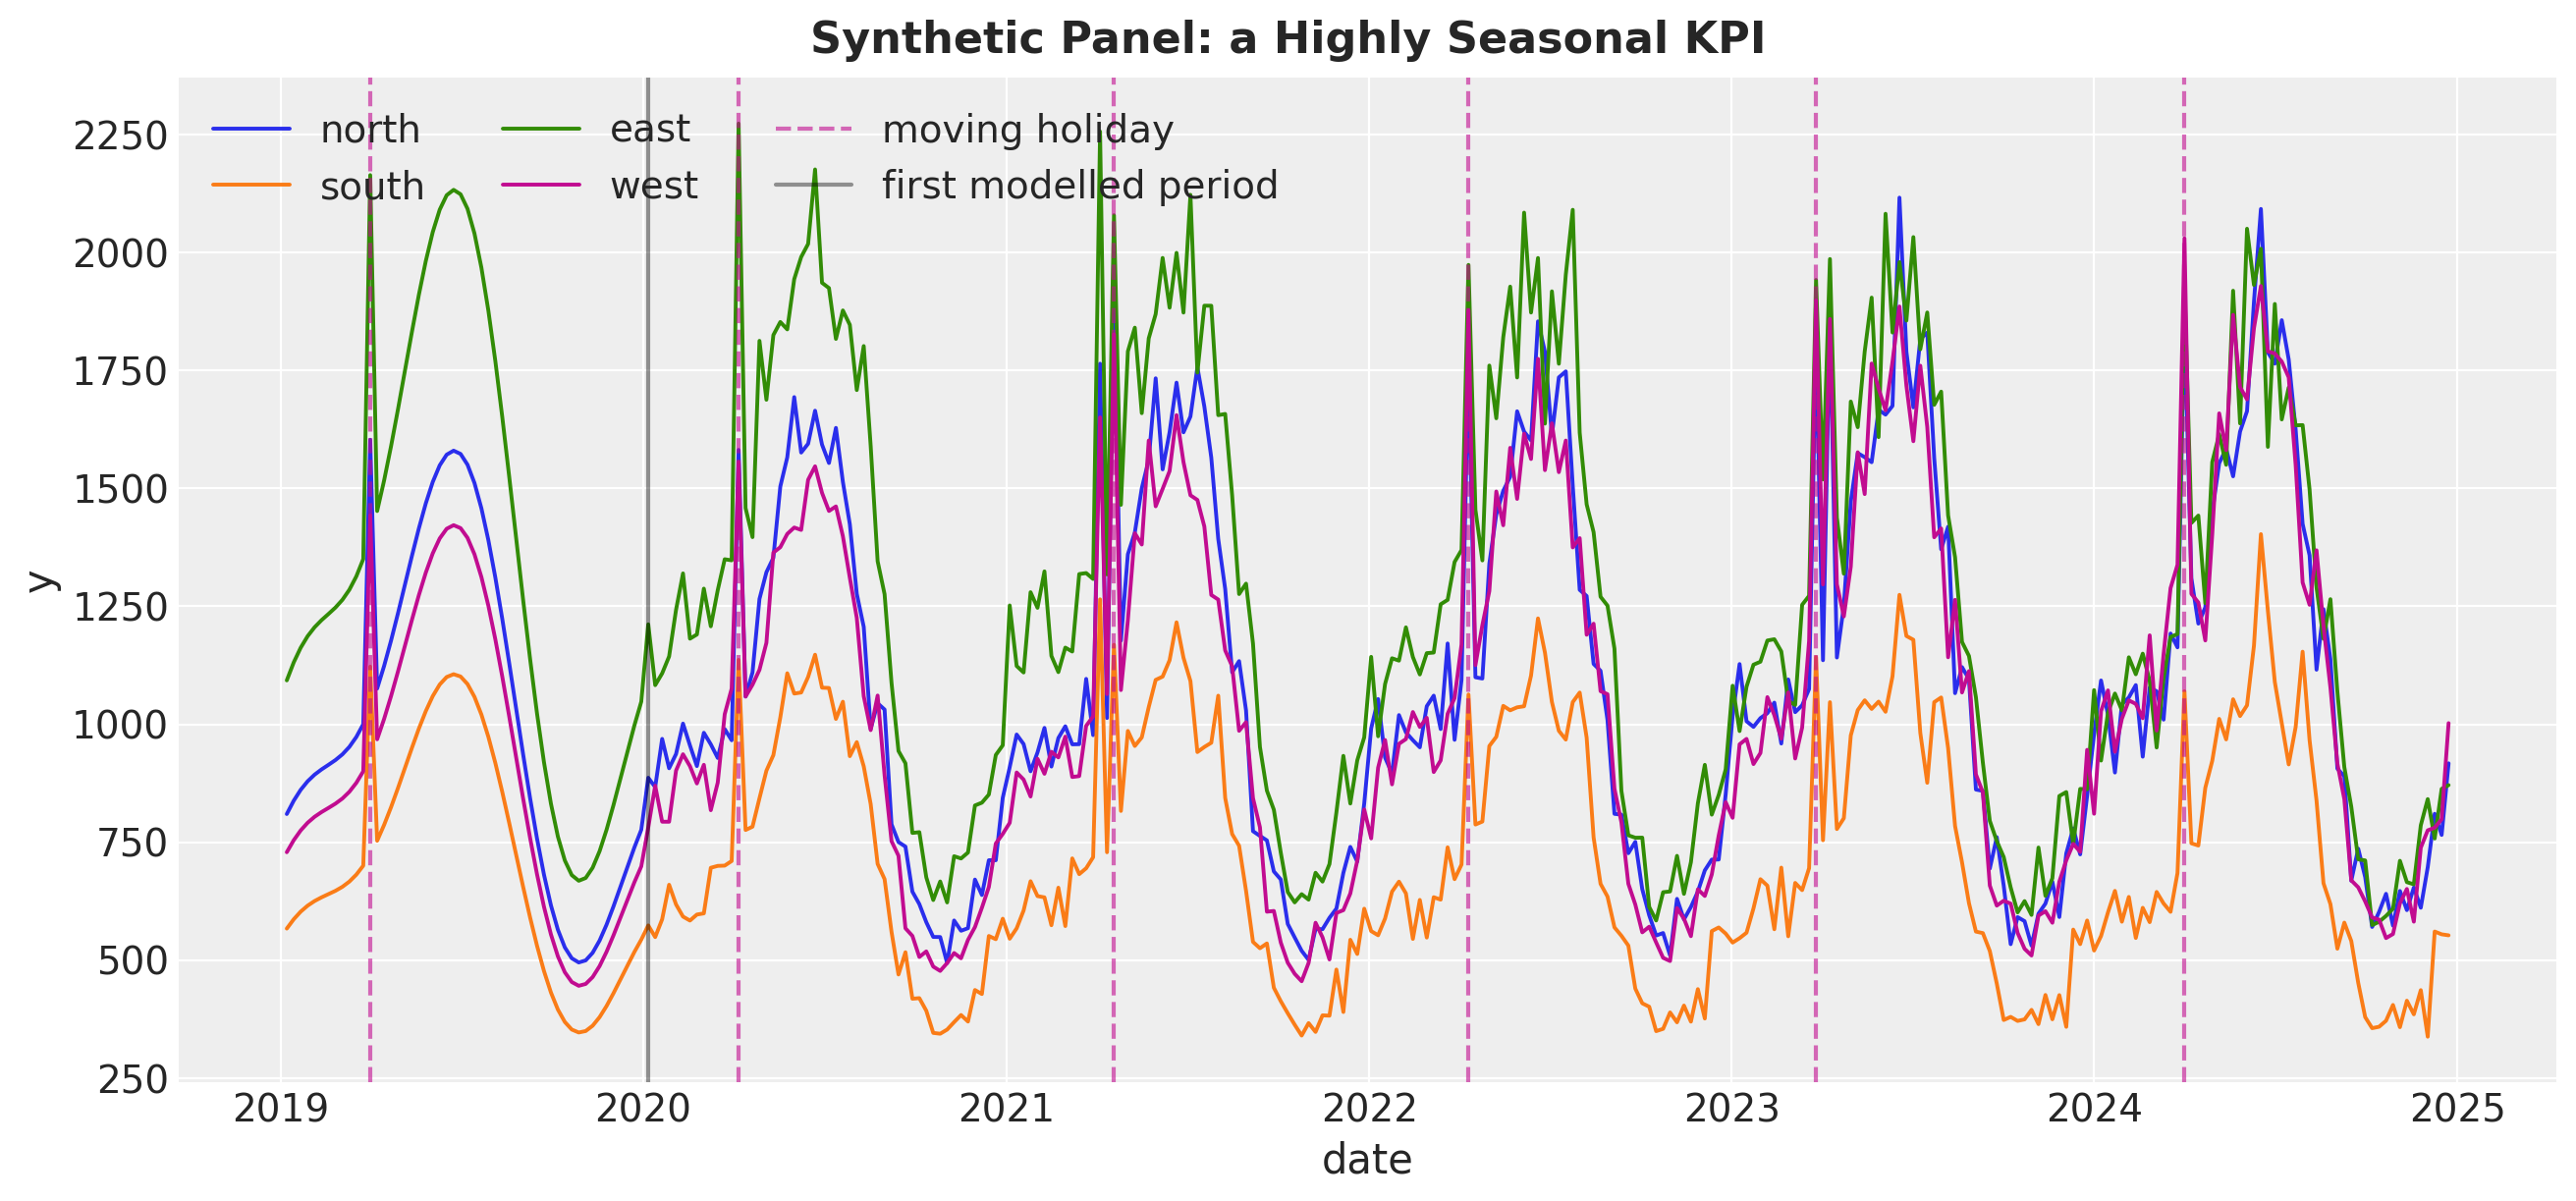

In [15]:
fig, ax = plt.subplots(figsize=(13, 6))

for unit in unit_names:
    ax.plot(date_index, target_data.sel(unit=unit), linewidth=1.4, label=unit)

for i, t in enumerate(holiday_index):
    ax.axvline(
        date_index[t],
        color="C3",
        linestyle="--",
        alpha=0.6,
        label="moving holiday" if i == 0 else None,
    )

ax.axvline(date_index[period], color="black", alpha=0.4, label="first modelled period")
ax.legend(loc="upper left", ncol=3)
ax.set(xlabel="date", ylabel="y")
fig.suptitle("Synthetic Panel: a Highly Seasonal KPI", fontsize=16, fontweight="bold")

The seasonal amplitude is large, it grows with the level, and the holiday spike wanders between
weeks 12 and 15. Now look at the same series after the transform, with the anchored map and with
a naive 52-week lag.

Text(0.5, 0.98, 'Year-over-Year Ratio: Anchored vs Naive Reference Map')

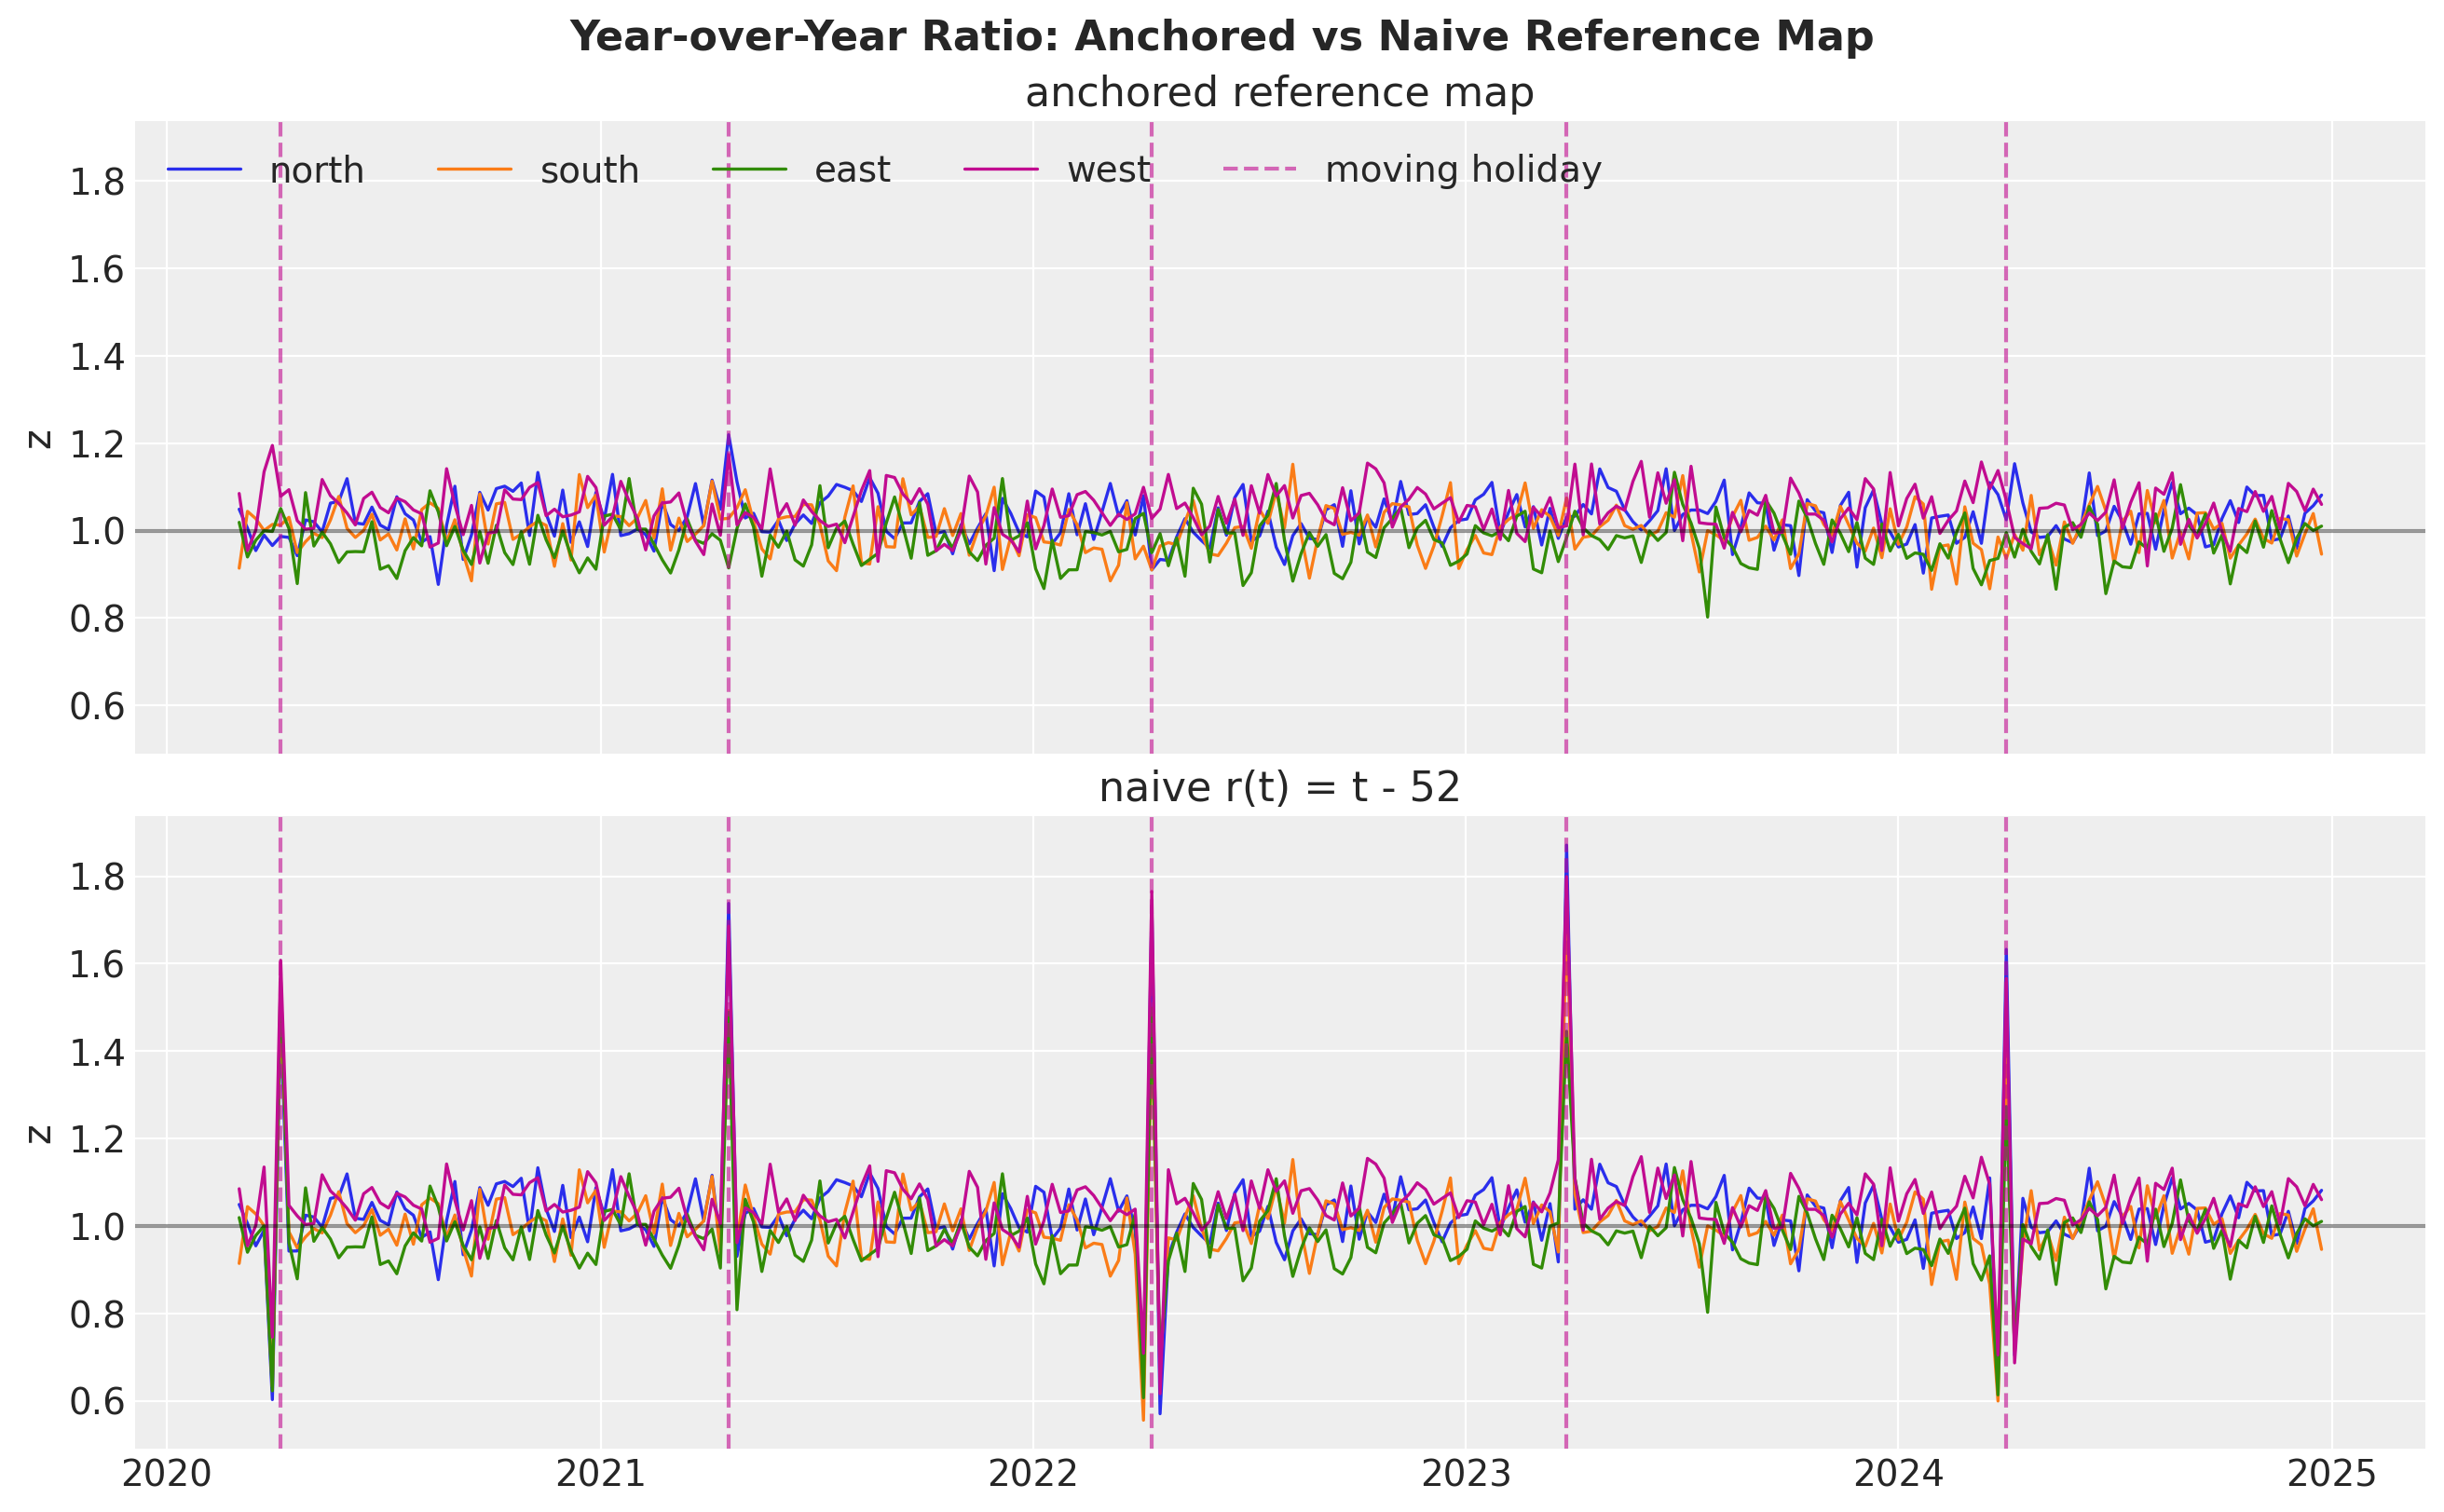

In [16]:
z_observed = xr.DataArray(
    y[obs_idx_model] / y[reference_map[obs_idx_model]],
    dims=("obs_date", "unit"),
    coords={"obs_date": date_index[obs_idx_model], "unit": unit_names},
)

z_naive = xr.DataArray(
    y[obs_idx_model] / y[naive_reference_map[obs_idx_model]],
    dims=("obs_date", "unit"),
    coords={"obs_date": date_index[obs_idx_model], "unit": unit_names},
)

fig, axes = plt.subplots(
    nrows=2, figsize=(13, 8), sharex=True, sharey=True, layout="constrained"
)

for unit in unit_names:
    axes[0].plot(
        z_observed["obs_date"], z_observed.sel(unit=unit), linewidth=1.2, label=unit
    )
    axes[1].plot(z_naive["obs_date"], z_naive.sel(unit=unit), linewidth=1.2, label=unit)

for ax, title in zip(
    axes, ["anchored reference map", "naive r(t) = t - 52"], strict=True
):
    for i, t in enumerate(holiday_index[1:]):
        ax.axvline(
            date_index[t],
            color="C3",
            linestyle="--",
            alpha=0.6,
            label="moving holiday" if i == 0 else None,
        )
    ax.axhline(1.0, color="black", alpha=0.4)
    ax.set_title(title)
    ax.set_ylabel("z")

axes[0].legend(loc="upper left", ncol=n_units + 1)
fig.suptitle(
    "Year-over-Year Ratio: Anchored vs Naive Reference Map",
    fontsize=16,
    fontweight="bold",
)

With the anchored map the ratio is a well-behaved series fluctuating around each unit's growth
rate. With the naive 52-week lag the same series carries a spike-and-crater pair at every moving
holiday, because a holiday week is being divided by a non-holiday week and vice versa. Those are
exactly the periods where the KPI is largest, so a model fitted on the naive ratio spends its
media coefficients explaining a calendar artifact.

In [17]:
naive_damage = pd.DataFrame(
    {
        "anchored": [float(z_observed.std()), float(np.abs(z_observed - 1).max())],
        "naive": [float(z_naive.std()), float(np.abs(z_naive - 1).max())],
    },
    index=["std of z", "max |z - 1|"],
)

naive_damage

,anchored,naive
std of z,0.059012,0.113616
max |z - 1|,0.219264,0.871043


## Fitting the year-over-year model

We hold out the last 52 weeks and train on everything before them. Every reference period for the
holdout window sits inside the training window, so the holdout prediction only needs observed
history, not model output.

In [18]:
n_test = period
obs_idx_train = obs_idx_model[:-n_test]
obs_idx_test = obs_idx_model[-n_test:]

train_dates = date_index[obs_idx_train]
test_dates = date_index[obs_idx_test]

print(
    f"train: {train_dates[0].date()} to {train_dates[-1].date()} ({len(obs_idx_train)} weeks)"
)
print(
    f"test:  {test_dates[0].date()} to {test_dates[-1].date()} ({len(obs_idx_test)} weeks)"
)

train: 2020-03-02 to 2023-12-25 (200 weeks)
test:  2024-01-01 to 2024-12-23 (52 weeks)


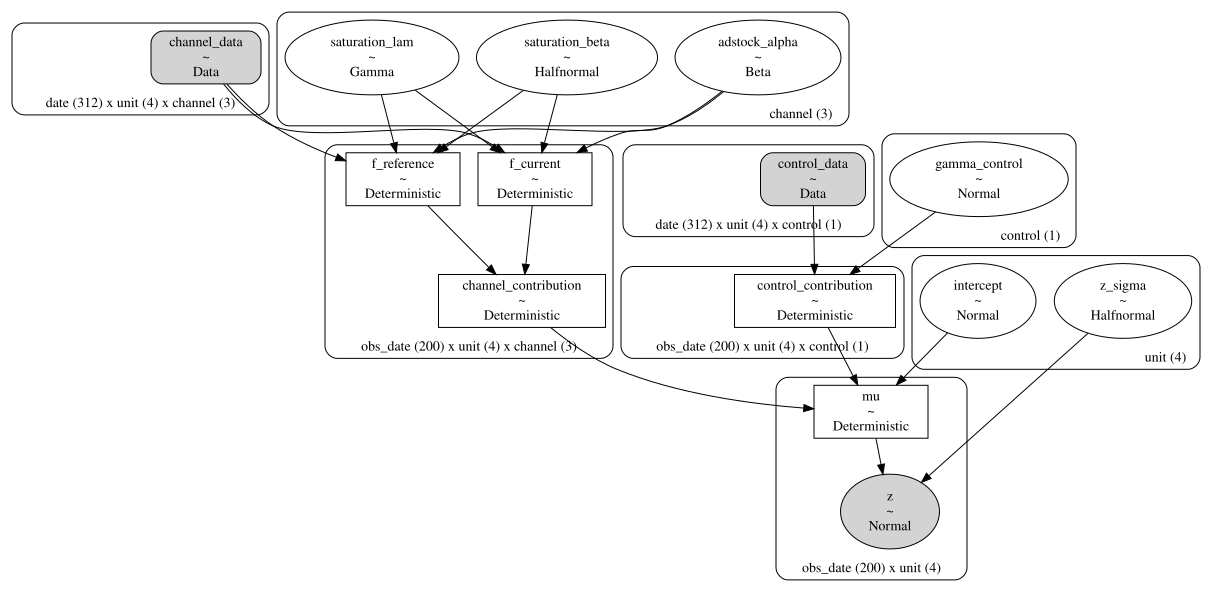

In [19]:
z_train = z_observed.isel(obs_date=slice(None, -n_test))

yoy_model = build_yoy_model(obs_idx_train, z_train)

pm.model_to_graphviz(yoy_model)

### Prior predictive check

Sampling: [adstock_alpha, gamma_control, intercept, saturation_beta, saturation_lam, z, z_sigma]


Text(0.5, 0.98, 'Prior Predictive Check (unit: north)')

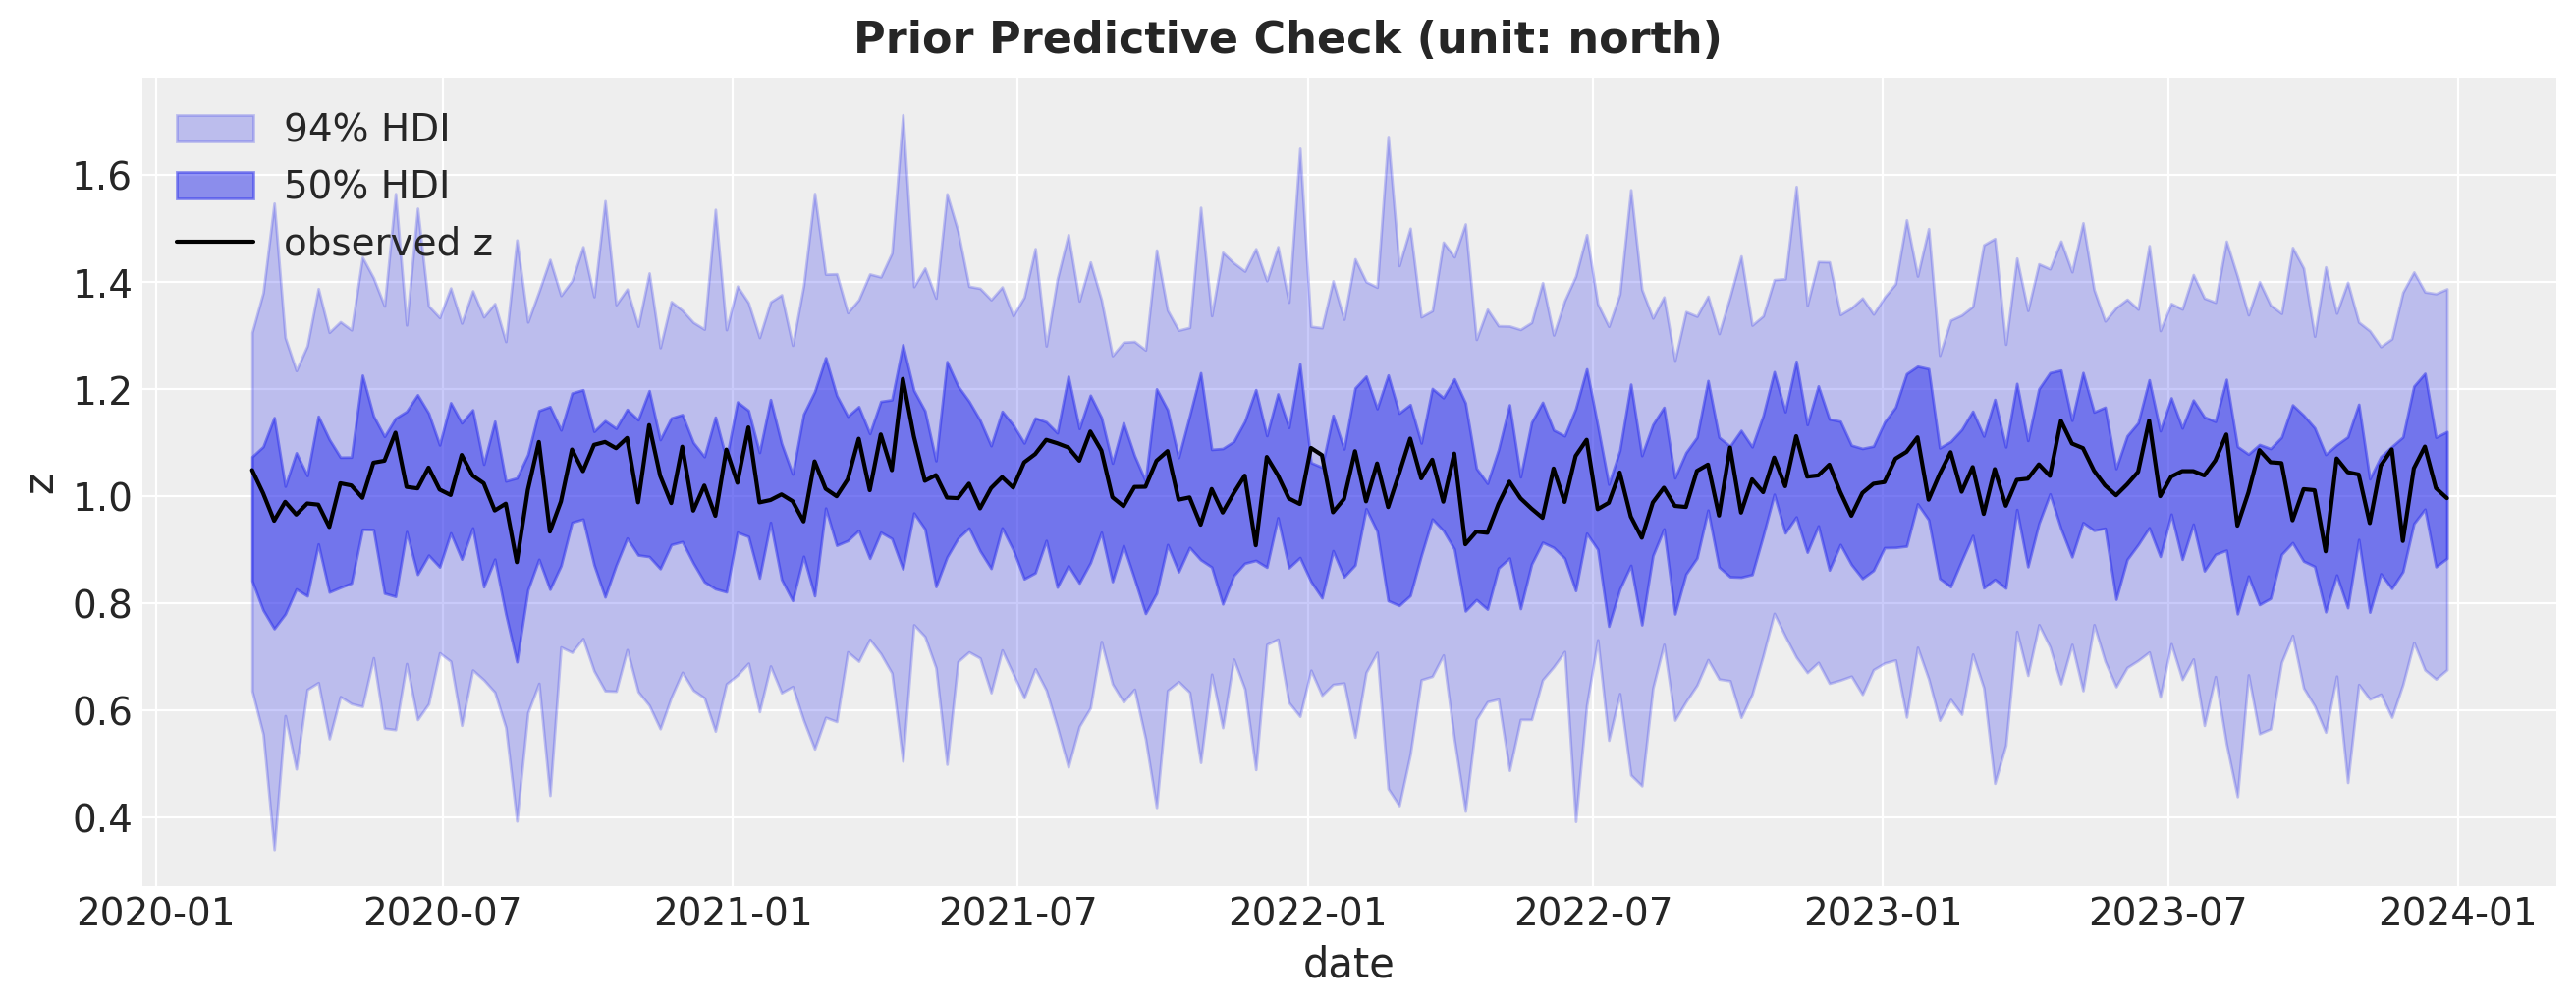

In [20]:
with yoy_model:
    yoy_prior = pm.sample_prior_predictive(draws=500, random_seed=rng)

fig, ax = plt.subplots(figsize=(13, 5))

for i, hdi_prob in enumerate([0.94, 0.5]):
    hdi = az.hdi(yoy_prior.prior_predictive["z"].sel(unit="north"), prob=hdi_prob)
    ax.fill_between(
        train_dates,
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        color="C0",
        alpha=0.25 + 0.25 * i,
        label=f"{hdi_prob:.0%} HDI",
    )

ax.plot(train_dates, z_train.sel(unit="north"), color="black", label="observed z")
ax.legend(loc="upper left")
ax.set(xlabel="date", ylabel="z")
fig.suptitle("Prior Predictive Check (unit: north)", fontsize=16, fontweight="bold")

In [21]:
with yoy_model:
    yoy_idata = pm.sample(
        chains=4,
        tune=1_000,
        draws=1_000,
        target_accept=0.9,
        nuts_sampler="nutpie",
        random_seed=rng,
    )
    pm.sample_posterior_predictive(
        yoy_idata, random_seed=rng, extend_inferencedata=True
    )

az.summary(yoy_idata, var_names=["intercept", "gamma_control", "z_sigma"], round_to=4)

NUTS[nutpie]: [adstock_alpha, saturation_lam, saturation_beta, gamma_control, intercept, z_sigma]


Output()

Sampling: [z]


Output()

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept[north],1.0297,0.0022,1.0262,1.0331,8851.2625,2950.7938,1.0004,0.0000,0.0
intercept[south],1.0022,0.0024,0.9985,1.0061,8628.3917,3047.8574,1.0023,0.0000,0.0
intercept[east],0.9762,0.0019,0.9731,0.9792,9154.5454,2533.8114,1.0021,0.0000,0.0
intercept[west],1.0488,0.0020,1.0456,1.0520,7873.9393,2905.1632,1.0068,0.0000,0.0
gamma_control[discount],0.1720,0.0056,0.1631,0.1810,7851.4913,3070.4611,1.0020,0.0001,0.0
z_sigma[north],0.0304,0.0015,0.0281,0.0330,8124.4915,2934.7589,1.0002,0.0000,0.0
z_sigma[south],0.0341,0.0018,0.0314,0.0370,9265.1390,3100.3986,0.9997,0.0000,0.0
z_sigma[east],0.0275,0.0014,0.0253,0.0297,7858.7950,3220.6260,1.0031,0.0000,0.0
z_sigma[west],0.0274,0.0014,0.0253,0.0297,8196.3192,3025.3124,1.0000,0.0000,0.0


The per-unit growth rates and the discount coefficient come back on target: the true values are
`intercept = [1.03, 1.00, 0.98, 1.05]` and `gamma_control = 0.18`.

### Parameter recovery

The data-generating process *is* this model, so the posteriors should concentrate on the true
values. Where they do not is the interesting part.

Text(0.5, 0.98, 'Parameter Recovery: Prior, Posterior, Truth')

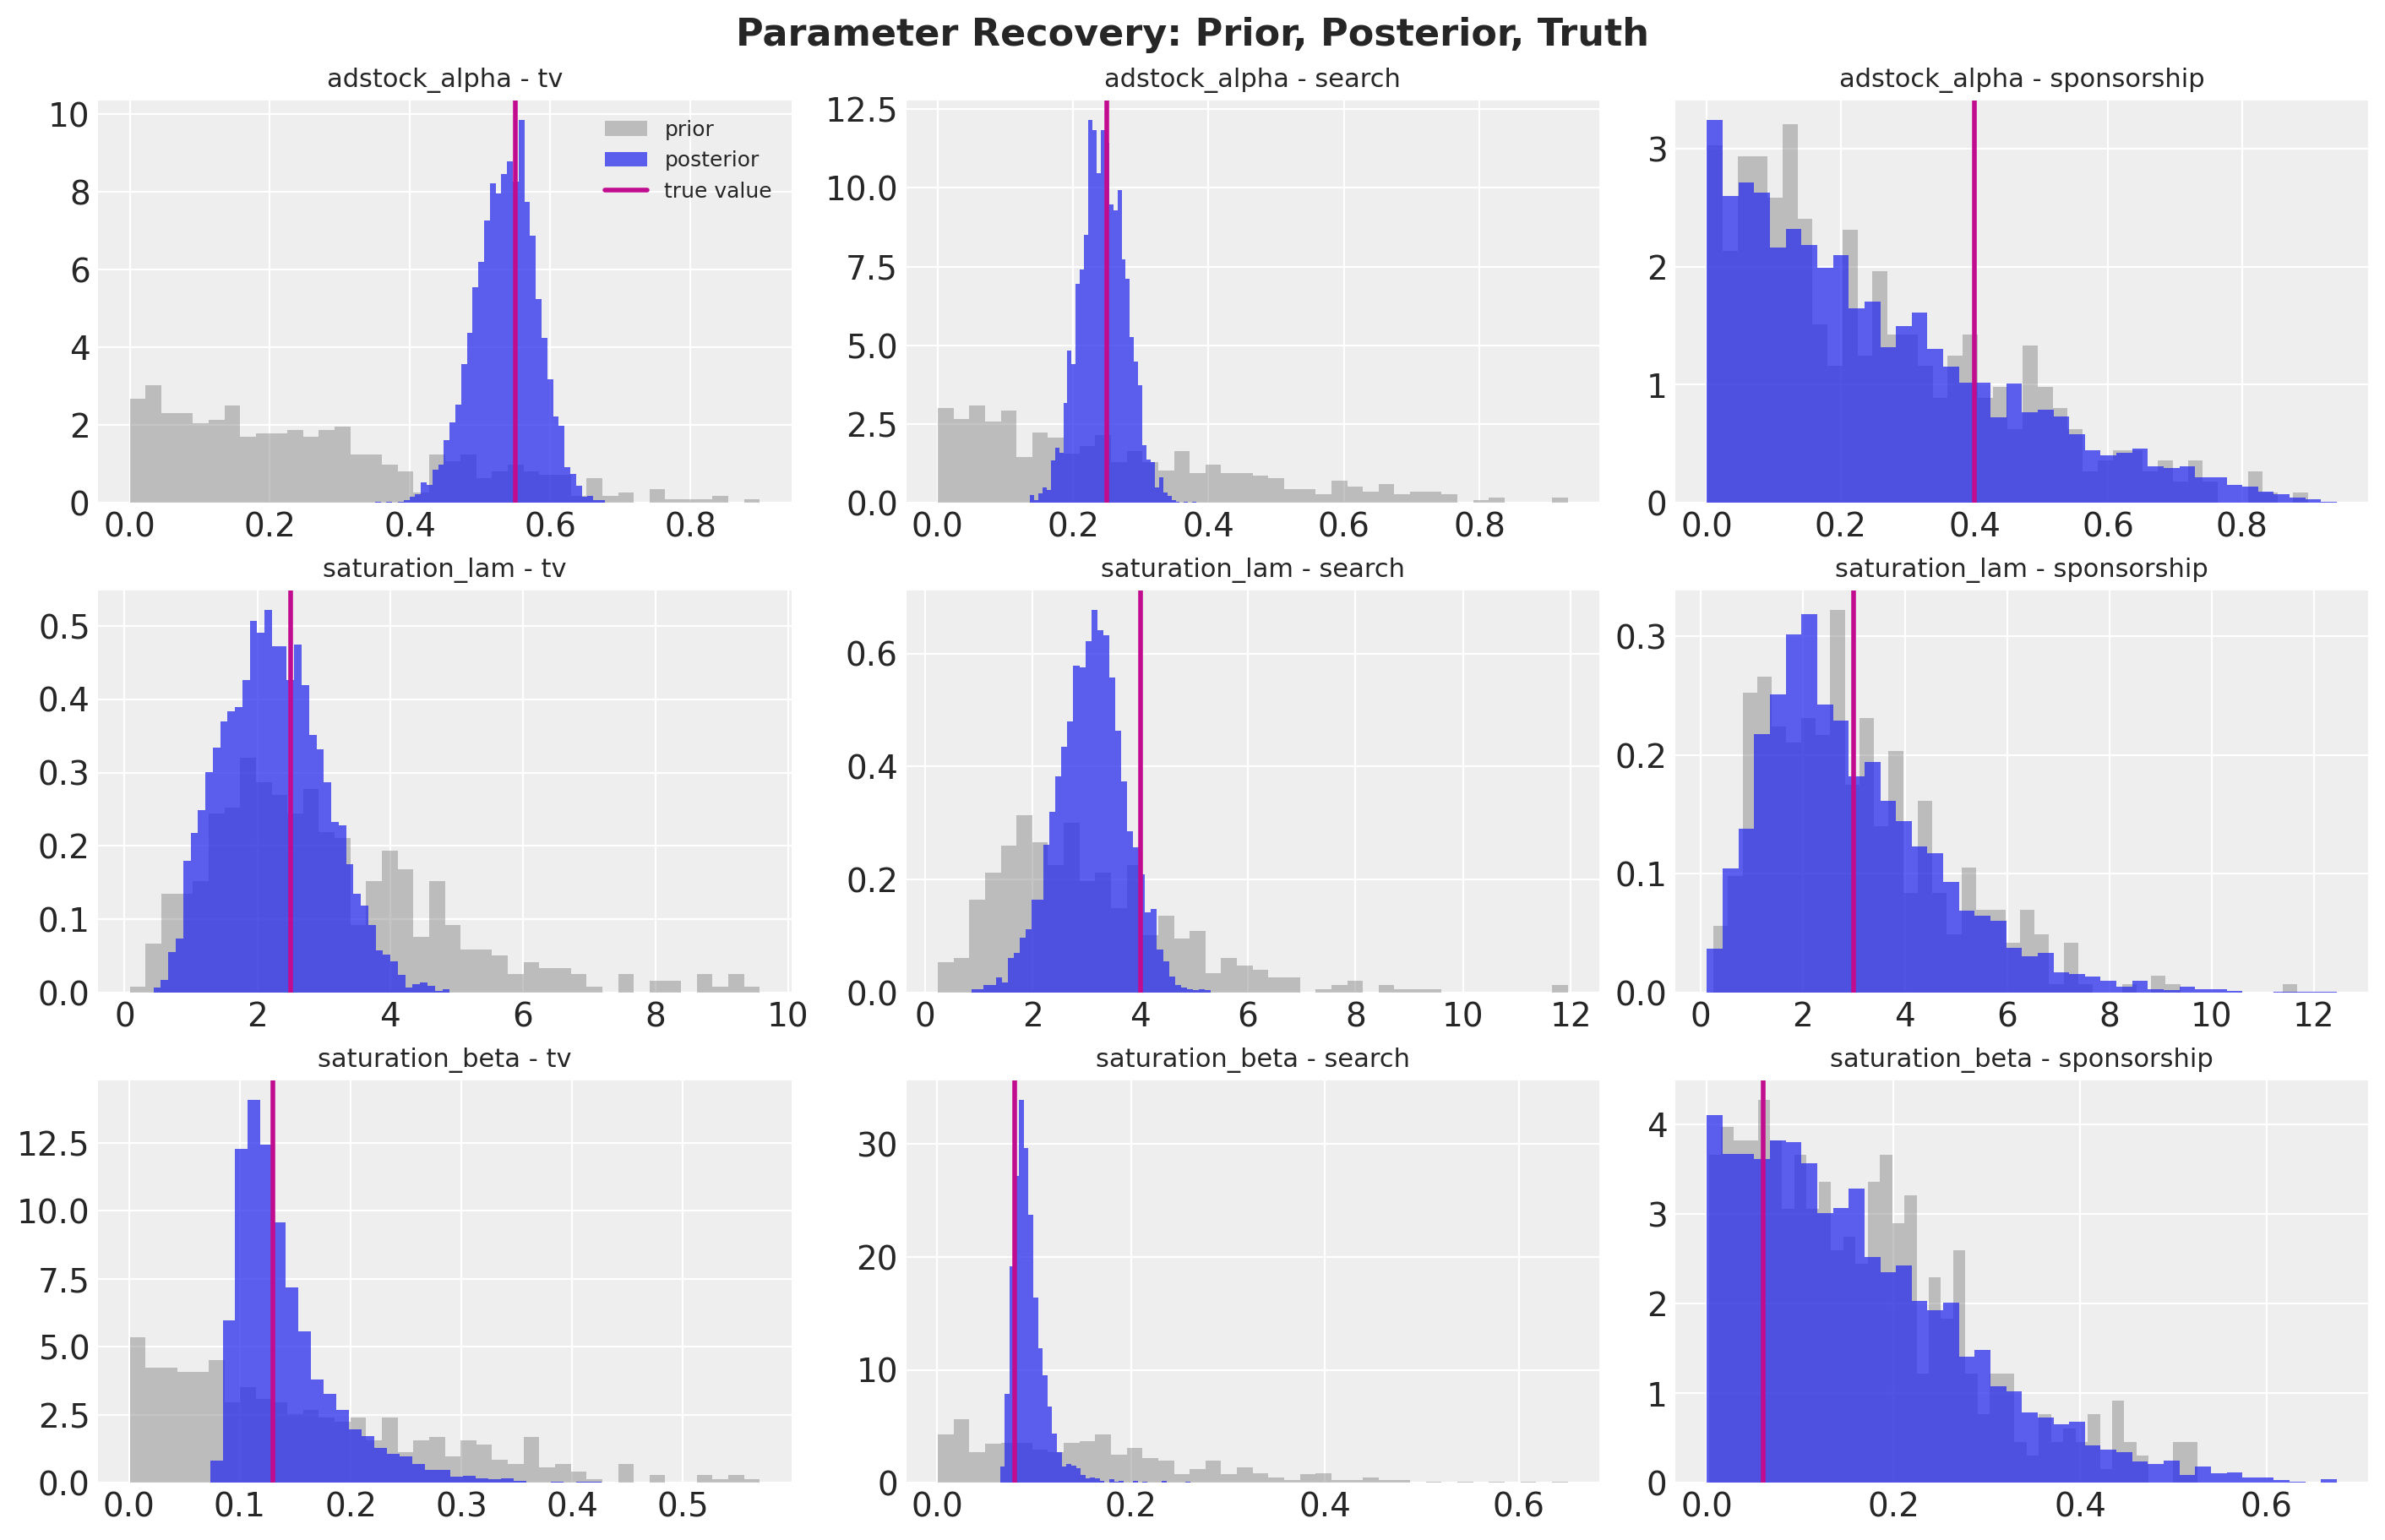

In [22]:
recovery_vars = ["adstock_alpha", "saturation_lam", "saturation_beta"]
truth_lookup = {
    "adstock_alpha": adstock_alpha_true,
    "saturation_lam": saturation_lam_true,
    "saturation_beta": saturation_beta_true,
}

fig, axes = plt.subplots(
    nrows=len(recovery_vars), ncols=n_channels, figsize=(14, 9), layout="constrained"
)

for row, var in enumerate(recovery_vars):
    for col, channel in enumerate(channel_columns):
        ax = axes[row, col]
        posterior_draws = (
            yoy_idata.posterior[var].sel(channel=channel).to_numpy().ravel()
        )
        prior_draws = yoy_prior.prior[var].sel(channel=channel).to_numpy().ravel()
        ax.hist(
            prior_draws, bins=40, density=True, color="grey", alpha=0.45, label="prior"
        )
        ax.hist(
            posterior_draws,
            bins=40,
            density=True,
            color="C0",
            alpha=0.75,
            label="posterior",
        )
        ax.axvline(truth_lookup[var][col], color="C3", linewidth=2, label="true value")
        ax.set_title(f"{var} - {channel}", fontsize=11)
        if row == 0 and col == 0:
            ax.legend(loc="upper right", fontsize=9)

fig.suptitle(
    "Parameter Recovery: Prior, Posterior, Truth", fontsize=16, fontweight="bold"
)

### The always-on channel is invisible

`tv` and `search` are recovered. `sponsorship` is not, and it never could be: its spend is
identical cycle over cycle, so $f_c(a_t) - f_c(a_{r(t)}) = 0$ for every modelled $t$, the channel
drops out of the likelihood entirely, and its posterior is exactly its prior. (This is also why
the modelled window starts $l_{\max}$ periods after the first cycle: without the burn-in drop the
reference periods at the very start of the series carry a partially warmed adstock, and the
always-on channel leaks a small amount of spurious information.)

This is a real property of the design rather than a bug, but it is the single most dangerous thing
about the transform in practice: a user who reads a tight posterior interval on such a channel is
reading a prior and calling it evidence. We can measure it directly.

In [23]:
def prior_posterior_shift(var: str) -> pd.DataFrame:
    """Compare prior and posterior spread, one row per coordinate."""
    prior_sd = yoy_prior.prior[var].std(("chain", "draw"))
    posterior_sd = yoy_idata.posterior[var].std(("chain", "draw"))
    return pd.DataFrame(
        {
            "prior sd": prior_sd.to_series(),
            "posterior sd": posterior_sd.to_series(),
            "sd ratio": (posterior_sd / prior_sd).to_series(),
        }
    )


prior_posterior_shift("saturation_beta")

,prior sd,posterior sd,sd ratio
channel,,,
tv,0.119400,0.047701,0.399505
search,0.116234,0.018211,0.156678
sponsorship,0.115571,0.120271,1.040665


A ratio near 1 means the likelihood said nothing. `sponsorship` sits there, and no amount of data
collected under a flat plan will move it. A year-over-year target model measures **plan changes**,
not programs.

## A vanilla additive MMM with Fourier seasonality

For the comparison we fit a standard multidimensional {class}`~pymc_marketing.mmm.mmm.MMM` on the
same panel, in level space, with yearly Fourier seasonality and the same adstock and saturation
families. It sees exactly the same training window and the same scaled spend.

In [24]:
panel_df = (
    channel_scaled.to_dataset(dim="channel")
    .to_dataframe()
    .reset_index()
    .merge(
        control_data.sel(control="discount", drop=True)
        .rename("discount")
        .to_dataframe()
        .reset_index(),
        on=["date", "unit"],
    )
    .merge(
        target_data.rename("y").to_dataframe().reset_index(),
        on=["date", "unit"],
    )
)

panel_df.head()

,date,unit,tv,search,sponsorship,discount,y
0,2019-01-07,north,0.697533,0.000024,1.000000,0.080188,809.657260
1,2019-01-07,south,0.241058,0.000126,0.348264,0.095377,566.760082
2,2019-01-07,east,0.308134,0.001998,0.959741,0.064830,1093.037301
3,2019-01-07,west,0.065462,0.459593,0.598403,0.204252,728.691534
4,2019-01-14,north,0.778724,0.000187,1.000000,0.030809,837.939690


In [25]:
train_df = panel_df[panel_df["date"].isin(train_dates)].reset_index(drop=True)
test_df = panel_df[panel_df["date"].isin(test_dates)].reset_index(drop=True)

X_train = train_df.drop(columns=["y"])
y_train = train_df["y"]

vanilla_mmm = MMM(
    date_column="date",
    channel_columns=channel_columns,
    control_columns=control_columns,
    target_column="y",
    adstock=GeometricAdstock(
        l_max=l_max, priors={"alpha": Prior("Beta", alpha=1, beta=3, dims="channel")}
    ),
    saturation=LogisticSaturation(
        priors={
            "lam": Prior("Gamma", alpha=3, beta=1, dims="channel"),
            "beta": Prior("HalfNormal", sigma=2, dims="channel"),
        }
    ),
    yearly_seasonality=4,
    dims=("unit",),
)

vanilla_mmm.build_model(X_train, y_train)

# Register the target on its original scale. Without this the posterior predictive comes back in
# the internally scaled space and is not comparable with the year-over-year predictions.
vanilla_mmm.add_original_scale_contribution_variable(var=["y"])

vanilla_idata = vanilla_mmm.fit(
    X_train,
    y_train,
    chains=4,
    tune=1_000,
    draws=1_000,
    target_accept=0.9,
    nuts_sampler="nutpie",
    random_seed=rng,
)

az.summary(
    vanilla_idata,
    var_names=["adstock_alpha", "saturation_lam", "y_sigma"],
    round_to=4,
)

NUTS[nutpie]: [y_sigma, gamma_fourier, gamma_control, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
adstock_alpha[tv],0.3745,0.1974,0.0629,0.7007,308.7913,397.5244,1.0123,0.0110,0.0062
adstock_alpha[search],0.1280,0.1006,0.0116,0.3123,1276.5430,1660.9119,1.0045,0.0027,0.0024
adstock_alpha[sponsorship],0.2262,0.1858,0.0170,0.6016,130.9311,486.7661,1.0301,0.0176,0.0142
saturation_lam[tv],1.8102,1.3047,0.3834,4.2218,273.5684,388.0793,1.0141,0.0690,0.0747
saturation_lam[search],2.1675,1.2618,0.5201,4.4058,421.2823,518.7165,1.0109,0.0586,0.0467
saturation_lam[sponsorship],2.7525,1.5892,0.7047,5.5977,104.6563,157.3912,1.0388,0.1560,0.1702
y_sigma[east],0.0612,0.0031,0.0566,0.0661,2294.1575,2342.2876,1.0035,0.0001,0.0000
y_sigma[north],0.0548,0.0028,0.0505,0.0595,2695.5214,2068.3868,1.0037,0.0001,0.0000
y_sigma[south],0.0331,0.0016,0.0305,0.0359,1331.9265,1393.1115,1.0031,0.0000,0.0000
y_sigma[west],0.0596,0.0031,0.0548,0.0646,2433.1258,2067.0622,1.0005,0.0001,0.0000


```{note}
The `saturation_beta` values of the two models are not comparable: one is in ratio points and the
other in KPI units. `adstock_alpha` is scale free, and both models see the same scaled spend, so
that one is.
```

## Out-of-sample comparison

Both models now predict the last 52 weeks in **KPI units**, which is the only scale on which they
are comparable.

- The year-over-year model predicts $z$ on the holdout window and multiplies by the observed
  reference level $y_{u,r(t)}$, which for this window sits entirely inside the training data.
- The vanilla model predicts $y$ directly, with `include_last_observations=True` so that its
  adstock carries over from the training window.

In [26]:
predict_model = build_yoy_model(obs_idx_test)

# Only the free parameters travel to the prediction model: the stored deterministics are shaped
# for the training window and would clash with the 52-week prediction window.
free_names = [rv.name for rv in predict_model.free_RVs]
posterior_free = yoy_idata.posterior.to_dataset()[free_names]

with predict_model:
    yoy_forecast = pm.sample_posterior_predictive(
        posterior_free, var_names=["z"], random_seed=rng, predictions=True
    )

y_reference_test = xr.DataArray(
    y[reference_map[obs_idx_test]],
    dims=("obs_date", "unit"),
    coords={"obs_date": test_dates, "unit": unit_names},
)

yoy_pred = (yoy_forecast.predictions["z"] * y_reference_test).rename(
    {"obs_date": "date"}
)

Sampling: [z]


Output()

In [27]:
vanilla_pp = vanilla_mmm.sample_posterior_predictive(
    X=test_df.drop(columns=["y"]),
    extend_idata=False,
    combined=False,
    include_last_observations=True,
    var_names=["y", "y_original_scale"],
    random_seed=rng,
)

vanilla_pred = vanilla_pp["y_original_scale"]

Sampling: [y]


Output()

In [28]:
y_test = target_data.sel(date=test_dates)


def score(pred: xr.DataArray, name: str) -> pd.Series:
    """Point and interval scores for a posterior predictive draw set, in KPI units."""
    mean = pred.mean(("chain", "draw"))
    hdi = az.hdi(pred, prob=0.94)
    lower = hdi.sel(ci_bound="lower")
    upper = hdi.sel(ci_bound="upper")
    return pd.Series(
        {
            "RMSE": float(np.sqrt(((mean - y_test) ** 2).mean())),
            "MAE": float(np.abs(mean - y_test).mean()),
            "MAPE (%)": float((np.abs(mean - y_test) / y_test).mean() * 100),
            "94% coverage": float(((y_test >= lower) & (y_test <= upper)).mean()),
            "mean 94% HDI width": float((upper - lower).mean()),
        },
        name=name,
    )


comparison = pd.concat(
    [score(yoy_pred, "year-over-year"), score(vanilla_pred, "vanilla + Fourier")],
    axis=1,
)

comparison

,year-over-year,vanilla + Fourier
RMSE,36.849878,147.062983
MAE,26.941147,103.229319
MAPE (%),2.591258,9.425230
94% coverage,0.894231,0.942308
mean 94% HDI width,116.132767,457.274431


The year-over-year model cuts holdout error by roughly a factor of four on both RMSE and MAPE,
with intervals about a quarter as wide. Read the two coverage numbers together with the two widths
rather than on their own: the level model reaches nominal coverage, but only by being wide
everywhere, because its residual scale is a single constant per unit and has to accommodate the
seasonal peak at every point of the cycle. The ratio model's uncertainty is rescaled by
$y_{u,r(t)}$ and so tracks the cycle for free; it lands slightly under nominal here, which is the
price of a noise model that is tight where the level is low.

Text(0.5, 0.98, 'Holdout Forecast, Last 52 Weeks')

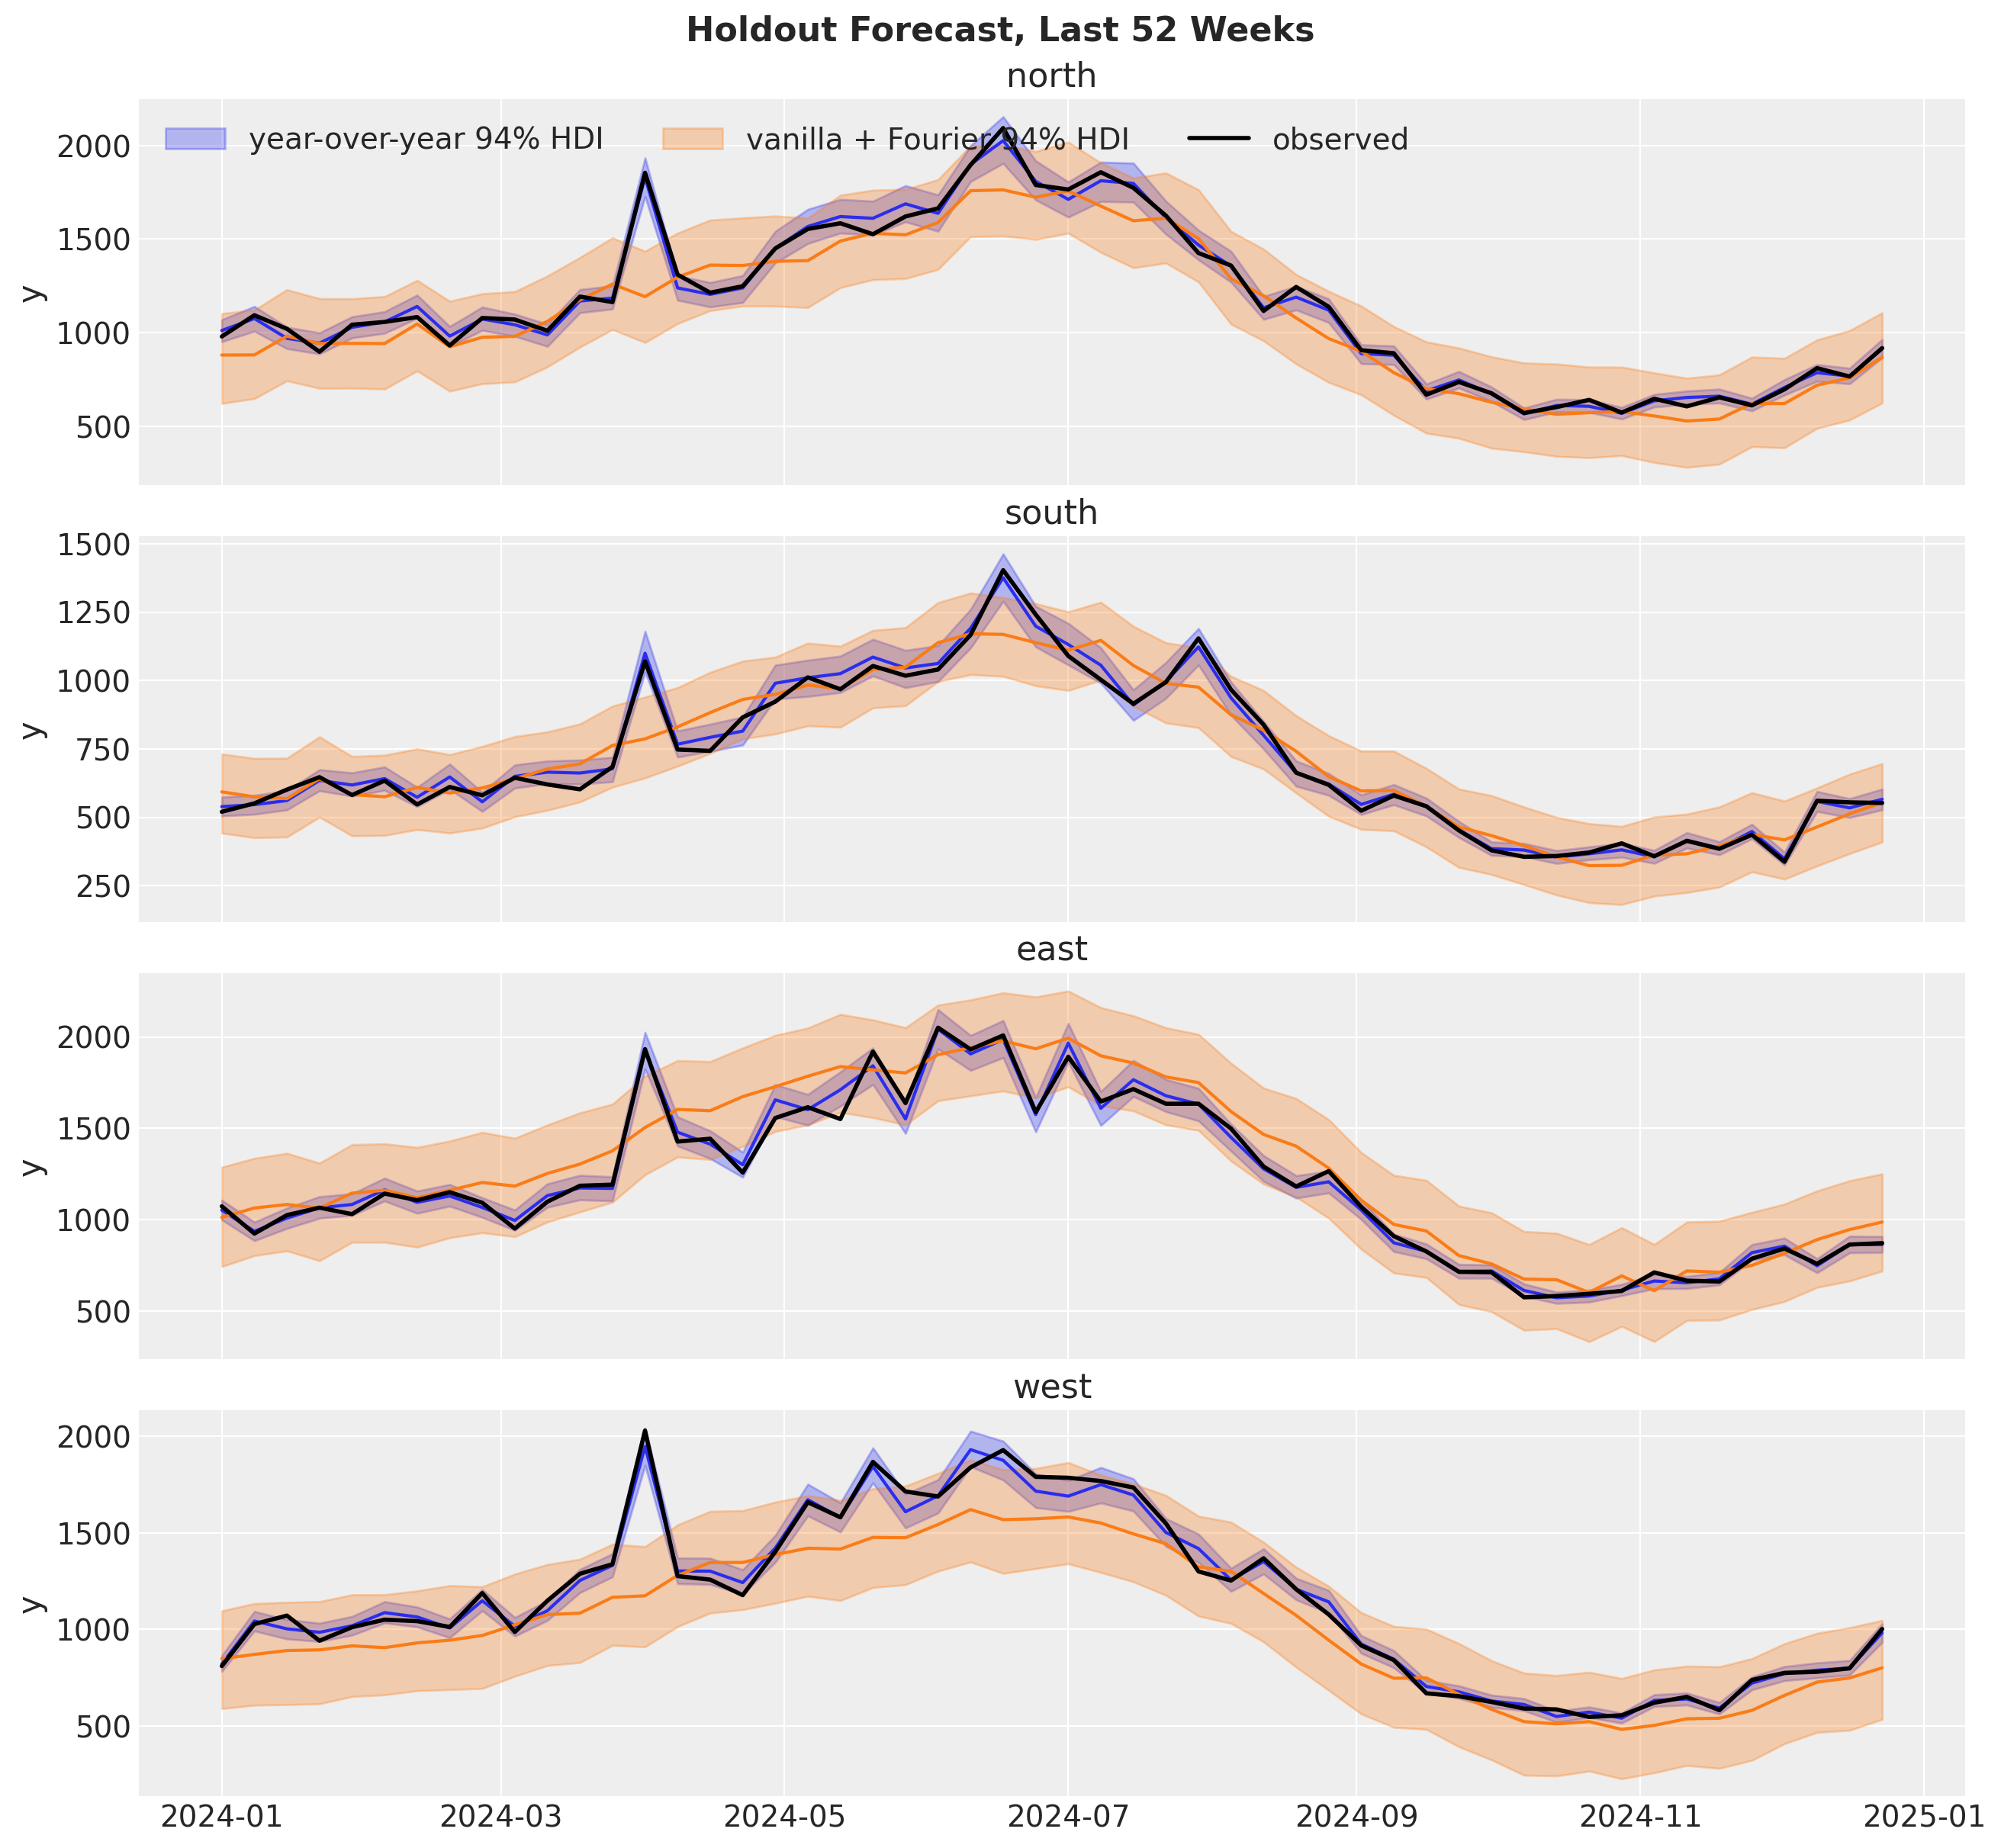

In [29]:
fig, axes = plt.subplots(
    nrows=n_units, figsize=(13, 3.0 * n_units), sharex=True, layout="constrained"
)

for ax, unit in zip(axes, unit_names, strict=True):
    for pred, color, label in [
        (yoy_pred, "C0", "year-over-year"),
        (vanilla_pred, "C1", "vanilla + Fourier"),
    ]:
        hdi = az.hdi(pred.sel(unit=unit), prob=0.94)
        ax.fill_between(
            test_dates,
            hdi.sel(ci_bound="lower"),
            hdi.sel(ci_bound="upper"),
            color=color,
            alpha=0.3,
            label=f"{label} 94% HDI",
        )
        ax.plot(
            test_dates,
            pred.sel(unit=unit).mean(("chain", "draw")),
            color=color,
            linewidth=1.5,
        )

    ax.plot(
        test_dates, y_test.sel(unit=unit), color="black", linewidth=2, label="observed"
    )
    ax.set_title(unit)
    ax.set_ylabel("y")

axes[0].legend(loc="upper left", ncol=3)
fig.suptitle("Holdout Forecast, Last 52 Weeks", fontsize=16, fontweight="bold")

## Contributions: two questions, two answers

Contributions have to be converted to KPI units **per unit-period**, by multiplying each
ratio-space part by that unit-period's own $y_{u,r(t)}$, and only then summed. Averaging ratio
contributions across a panel and scaling the average by a single reference factor is a different
number, and the discrepancy grows with dispersion in unit size.

A closure check that only asserts the national total will pass even when a constant has been
misplaced across the baseline and control split, so we assert the invariant at unit-period grain.

In [30]:
posterior = yoy_idata.posterior.to_dataset()

y_reference_train = xr.DataArray(
    y[reference_map[obs_idx_train]],
    dims=("obs_date", "unit"),
    coords={"obs_date": train_dates, "unit": unit_names},
)

parts_ratio = {
    "baseline": posterior["intercept"].broadcast_like(posterior["mu"]),
    **{
        f"media[{channel}]": posterior["channel_contribution"].sel(channel=channel)
        for channel in channel_columns
    },
    **{
        f"control[{control}]": posterior["control_contribution"].sel(control=control)
        for control in control_columns
    },
}

parts_kpi = {name: part * y_reference_train for name, part in parts_ratio.items()}
residual_kpi = (z_train - posterior["mu"]) * y_reference_train

total_kpi = sum(parts_kpi.values()) + residual_kpi
np.testing.assert_allclose(
    total_kpi.mean(("chain", "draw")).transpose("obs_date", "unit").to_numpy(),
    (z_train * y_reference_train).transpose("obs_date", "unit").to_numpy(),
    rtol=1e-8,
)
print("per unit-period closure check passed")

per unit-period closure check passed


In [31]:
contrast_basis = pd.Series(
    {
        name: float(part.sum(("obs_date", "unit")).mean(("chain", "draw")))
        for name, part in parts_kpi.items()
    },
    name="contrast basis",
)

contrast_basis.to_frame()

,contrast basis
baseline,827889.087173
media[tv],-2.358187
media[search],341.774598
media[sponsorship],0.000000
control[discount],82.619618


Note that a contrast-basis media number can be **negative**: it is the effect of the change in
plan, so a channel whose spend fell relative to the previous cycle contributed negatively. That is
the correct answer to the question being asked, and it is one reason the contrast basis is easy to
misread as a total.

### The level basis needs a declared reference point

The numbers above answer *"what did the change in plan versus last cycle contribute?"*. They are
read directly off the fitted terms and they are identified.

The other question, *"what did this channel contribute in total?"*, needs the exact regrouping

$$
f_c(a_t) - f_c(a_{\text{ref}}) \;=\;
\underbrace{\bigl[f_c(a^\ast) - f_c(a_{\text{ref}})\bigr]}_{\text{moves into the baseline}}
\;+\; \underbrace{\bigl[f_c(a_t) - f_c(a^\ast)\bigr]}_{\text{reported as the channel level}}
$$

for a declared reference point $a^\ast$. The regrouping is algebraically exact. The *number* is
not, because with $a^\ast = 0$ it depends on the shape of $f_c$ over a range the data never
visited. Under logistic saturation $f_c(0) = 0$, so the level read is simply $f_c(a_t)$ and the
baseline absorbs $-f_c(a_{\text{ref}})$.

The level read is levered off the measured contrast by roughly

$$
\frac{\lVert f_c(a_t) - f_c(a^\ast) \rVert}{\lVert f_c(a_t) - f_c(a_{\text{ref}}) \rVert},
$$

which for a channel whose spend barely moved cycle over cycle is a large multiplier on a small
measured quantity.

In [32]:
f_current = posterior["f_current"]
f_reference = posterior["f_reference"]

level_parts_kpi = {
    "baseline": parts_kpi["baseline"]
    - (f_reference.sum("channel") * y_reference_train),
    **{
        f"media[{channel}]": f_current.sel(channel=channel) * y_reference_train
        for channel in channel_columns
    },
    **{
        f"control[{control}]": parts_kpi[f"control[{control}]"]
        for control in control_columns
    },
}

# The regrouping is exact: the two bases add up to the same total.
np.testing.assert_allclose(
    sum(level_parts_kpi.values())
    .mean(("chain", "draw"))
    .transpose("obs_date", "unit")
    .to_numpy(),
    sum(parts_kpi.values())
    .mean(("chain", "draw"))
    .transpose("obs_date", "unit")
    .to_numpy(),
    rtol=1e-8,
)

level_basis = pd.Series(
    {
        name: float(part.sum(("obs_date", "unit")).mean(("chain", "draw")))
        for name, part in level_parts_kpi.items()
    },
    name="level basis (a* = 0)",
)

pd.concat([contrast_basis, level_basis], axis=1)

,contrast basis,level basis (a* = 0)
baseline,827889.087173,689662.759706
media[tv],-2.358187,28985.176185
media[search],341.774598,17402.714357
media[sponsorship],0.000000,92177.853337
control[discount],82.619618,82.619618


The two columns are two answers to two different questions about the same fit. The media rows on
the level basis are far larger, and they are not measurements of the same quality. The leverage
diagnostic below says by how much.

In [33]:
leverage = pd.DataFrame(
    {
        "measured contrast": np.abs(posterior["channel_contribution"])
        .mean(("chain", "draw", "obs_date", "unit"))
        .to_series(),
        "level read (a* = 0)": np.abs(f_current)
        .mean(("chain", "draw", "obs_date", "unit"))
        .to_series(),
    }
)
leverage["leverage"] = leverage["level read (a* = 0)"] / leverage["measured contrast"]

leverage

,measured contrast,level read (a* = 0),leverage
channel,,,
tv,0.013366,0.034688,2.595205
search,0.021130,0.020484,0.969462
sponsorship,0.000000,0.108334,inf


The leverage column is the health check. A value near 1 means the level statement is about as
well-measured as the contrast. A large value means the level number is an extrapolation of the
saturation curve into territory the data never visited, dressed up as a measurement. For
`sponsorship` the measured contrast is exactly zero and the leverage is infinite: there is no
defensible total-contribution number for that channel under this parameterisation, at any
posterior width. Budget optimisation and response curves live on the level basis and inherit that
dependence.

## Learnings and conclusions

**On the transform itself.**

1. **Seasonality really is free.** The year-over-year model carries no Fourier basis, no trend and
   no per-unit seasonal profile, yet on a 52-week holdout of a strongly seasonal panel it beats a
   level-space model with four yearly harmonics by roughly a factor of four on both RMSE and MAPE.
   The per-unit baseline collapses from a curve to a scalar growth rate, which is where most of the
   parameters in a level-space panel MMM go.
2. **Additive noise in ratio space is proportional noise in levels.** Both models land near nominal
   coverage on the holdout, but the level model needs intervals about four times wider to get
   there: its residual scale is one constant per unit and has to cover the seasonal peak
   everywhere. Compare coverage and interval width together, never coverage alone.
3. **The reference map is the load-bearing component, not a preprocessing detail.** With a naive
   52-week lag the ratio series carries a spike-and-crater pair at every moving holiday, and the
   media coefficients get spent explaining a calendar artifact. Event anchoring fixes the pairing
   and, unavoidably, introduces $k$ duplicated and $k$ orphaned reference periods at each window
   edge. Period-level reads are unaffected; cycle-level roll-ups are not, so an aggregation helper
   has to declare a convention rather than quietly double-count.

**On what the likelihood can identify.**

4. **Media appears only as a contrast.** An always-on channel at flat spend drops out of the
   likelihood exactly, and its posterior is its prior. The prior-to-posterior standard deviation
   ratio is a one-line diagnostic that belongs next to any coefficient table from such a model.
   The transform measures plan changes, not programs.
5. **The level of $f$ is not identified, so there are two attribution questions.** The contrast
   basis is identified and publishable. The level basis is an exact regrouping around a declared
   $a^\ast$, and its leverage over the measured contrast is a number worth reporting alongside it.
6. **Controls behave better than media.** They enter as raw differences through a linear
   coefficient, so $\gamma_k (x_t - x_{\text{ref}}) = \gamma_k x_t - \gamma_k x_{\text{ref}}$ holds
   exactly and the contrast-identified $\gamma_k$ *is* the level coefficient. The only free choice
   is where to declare $x_k^\ast$. Controls that are already a rate before differencing become a
   second difference after it and have no sensible level interpretation at all; those belong in a
   declared difference-only bucket.
7. **Dollarise before aggregating.** Each ratio-space part has to be multiplied by that
   unit-period's own $y_{u,r(t)}$ and only then summed, and the closure invariant has to be
   asserted at unit-period grain.

**When not to use it.** The panel above was generated from this model's own assumption: a seasonal
shape that genuinely repeats cycle over cycle, with proportional noise. That is the transform's
home turf, and the holdout margin should be read as *what the level model pays when the assumption
holds*, not as a general ranking. If the seasonal shape itself is drifting, if the KPI can touch
zero or go negative, or if the media plan is stable and the question is total contribution rather
than incremental change, a level-space model with an explicit seasonal basis is the better tool.
`MMM(link="log")` sits between the two: multiplicative like this transform, but still requiring an
explicit seasonal basis and still identifying media at the level rather than the contrast.

**Where this could go in PyMC-Marketing.** The self-contained piece is `build_reference_map`: the
event-anchored $r(t)$ with its shoulder windows and its duplicate/orphan diagnostics is useful on
its own, independently of any model. Everything else in this notebook is a consumer of that one
object, which is an argument for making the reference map a first-class component rather than
hiding the divisor inside a scaler.

In [34]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Fri, 07 Aug 2026

Python implementation: CPython
Python version       : 3.12.13
IPython version      : 9.15.0

pymc_marketing: 1.0.0
pytensor      : 3.0.7

arviz         : 1.2.0
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pymc          : 6.0.1
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0
pytensor      : 3.0.7
xarray        : 2026.4.0

Watermark: 2.6.0

